### Análisis exploratorio de datos - _Derechos de uso de aguas DINAGUA_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




#### 1) Definición del problema


Para este trabajo se utilizará un dataset proveniente del Sistema de Información Hídrica (SIH), el cual contiene información sobre los Derechos de Uso de Aguas otorgados por la Dirección Nacional de Aguas (DINAGUA) a personas físicas y jurídicas.

El SIH incluye datos asociados a obras de captación de aguas superficiales (tomas y embalses) y subterráneas (pozos). Los datos utilizados provienen una vez que el usuario solicita el derecho en el [Registro de usuarios para trámites de derechos de uso de aguas](https://www.gub.uy/tramites/registro-usuarios-tramites-derechos-uso-aguas).

Dado que el presente análisis se centra en los recursos hídricos subterráneos, se trabajará exclusivamente con los registros correspondientes a pozos.



Posteriormente, se realizará un proceso de exploración, limpieza y preparación de los datos para obtener un conjunto de datos adecuado para el entrenamiento de modelos de Machine Learning. El objetivo es analizar la demora de los trámites de habilitación y las variables que influyen en la duración del trámite de forma de mejorar su gestión.



#### 2) Recopilación de datos


A continuación, se presenta una breve descripción de las variables incluidas en la base de datos, con el objetivo de facilitar la comprensión de la información disponible y su posterior análisis.


| Variable | Descripción |
|-----------|-------------|
| Nro. GEX | Número de expediente |
| Fecha Vencimiento | Vencimiento del derecho de uso de aguas públicas, máximo 10 años, pero depende del uso que se le va a dar al agua. |
| Estado | Estado de la solicitud ante Dinagua: en estudio, pendiente de resolución, registrada. |
| Regional | Oficina de Dinagua encargada del estudio de la solicitud. |
| Departamento | Ubicación de la perforación. |
| Fecha de Resolución | Fecha en la que se emite el derecho de uso de aguas públicas. |
| Caudal | m³/h de extracción de agua autorizados por Dinagua. |
| Volumen | Volumen anual de extracción de agua (Volumen = caudal × hs/día × día/mes × mes/año). |
| Uso | Clasificación general de cuál es el uso que se le va a dar al agua que se extrae. |
| Destino | Subcategoría de uso. Finalidad específica del agua que se extrae. |
| Latitud | Ubicación de la perforación. |
| Longitud | Ubicación de la perforación. |
| Mes Inicio | En qué mes del año se comienza con la extracción de agua. |
| Mes Final | En qué mes del año se finaliza con la extracción de agua. |
| Horas x Año | Cantidad de horas anuales de extracción de agua. |
| Depto.-Padrón | Ubicación de la perforación. |
| Tipo de Obra | En este caso el tipo de obra es perforación. |
| Id Solicitud | Identificador único. |
| Codigo Cuencas de nivel 5 | Cuencas hidrográficas. |
| Sección y localidad catastral | Sección y localidad catastral a la que pertenece el padrón. |
| Cuencas de nivel 3 | Cuencas hidrográficas. |
| Curso a Utilizar | Dato no útil. Relacionado con obras del tipo superficial. |
| Tipo de acuífero | Tipo de acuífero desde donde se obtiene el agua subterránea a extraer. Puede ser fisurado, sedimentario o ambos. |
| Profundidad | Profundidad en metros de la perforación. |
| Diámetro | Diámetro en milímetros de la perforación. |
| Caudal Ensayado | Caudal obtenido en el momento del ensayo de bombeo, medido en m³. |
| Nivel Estático | Profundidad a la que está el agua cuando el pozo no es utilizado por un período mayor a 8 horas, en relación al nivel de superficie. |
| Nivel Dinámico | Profundidad a la que está el agua cuando el pozo está en uso, en relación al nivel de superficie. |
| Caudal Máximo | Dato no útil. |
| Codigo Cuencas de nivel 2 | Cuencas hidrográficas. |
| Producción | Dato no útil. |

#### 2) Importación de dataset y creación del dataframe

In [2]:
df = pd.read_csv("../data/raw/Base_de_datos_Python_GRUPOA.csv", sep=";")

In [3]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,55,"0,15","19,7",20,"37,5",NaN,14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53,"0,15",9,25,29,NaN,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31,"0,15",25,2,5,NaN,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,55,"0,15",20,28,"32,5",NaN,24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,64,"0,15","6,8","3,9","22,3",NaN,63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(5700, 38)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5700 entries, 0 to 5699
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tipo de Solicitud              5159 non-null   str    
 1   Nro. GEX                       5157 non-null   str    
 2   Fecha Vencimiento              4700 non-null   str    
 3   Estado                         5159 non-null   str    
 4   Regional                       5157 non-null   str    
 5   Departamento                   5157 non-null   str    
 6   Tecnicos                       5142 non-null   str    
 7   Fecha de Solicitud             5158 non-null   str    
 8   Fecha de Resolución            4699 non-null   str    
 9   Fecha de Inscripción           4653 non-null   str    
 10  Caudal                         5113 non-null   str    
 11  Volumen                        5127 non-null   str    
 12  Uso                            5159 non-null   str    
 13 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Mes Inicio,5123.0,6.718915,5.342711,1.0,1.0,10.0,12.00,12.0
Mes Final,5123.0,9.740582,3.386649,0.0,10.0,11.0,12.00,12.0
Horas x Año,5121.0,3128.130443,1866.384298,1.0,1600.0,2880.0,4320.00,9000.0
Id Solicitud,5159.0,249482.421012,6255.075576,237902.0,244274.5,249362.0,254852.50,261225.0
Codigo Cuencas de nivel 5,5152.0,37711.344332,18888.650444,10105.0,22600.0,27400.0,58171.25,68710.0
Sección y localidad catastral,3387.0,5.623561,13.541791,0.0,2.0,4.0,7.00,746.0
Caudal Máximo,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Codigo Cuencas de nivel 2,5152.0,37.194682,18.909617,10.0,22.0,27.0,58.00,68.0



#### 3) Limpieza de datos

_- Eliminación de duplicados_

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5695     True
5696     True
5697     True
5698     True
5699     True
Length: 5700, dtype: bool

In [8]:
df.duplicated().sum()

np.int64(540)

Se identifican 540 filas duplicadas dentro del conjunto de datos que representan aproximadamente el 9,47% del total de observaciones. A continuación se inspeccionan filas duplicadas para confirmarlas y entenderlas previo a eliminarlas.

In [9]:
df[df.duplicated()].head()

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
5160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.tail(10)

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
5690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parecería que las últimas filas del dataset están todas vacías y por lo tanto duplicadas entre si. A continuación se cuentan las filas completamente vacías para confirmar que las filas duplicadas están todas vacías.

In [11]:
df.isnull().all(axis=1).sum()

np.int64(541)


Se verifica la existencia de 541 filas completamente vacías sin información en ninguna de sus variables y, que además, generan 540 registros duplicados dentro del dataset. Por este motivo, se procede a su eliminación.

In [12]:
df = df.dropna(how="all")

In [13]:
print("Filas vacías:", df.isnull().all(axis=1).sum())
print("Duplicados:", df.duplicated().sum())
print("Dimensión:", df.shape)

Filas vacías: 0
Duplicados: 0
Dimensión: (5159, 38)


In [14]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,55,"0,15","19,7",20,"37,5",NaN,14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53,"0,15",9,25,29,NaN,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31,"0,15",25,2,5,NaN,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,55,"0,15",20,28,"32,5",NaN,24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,64,"0,15","6,8","3,9","22,3",NaN,63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaN,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,23/Mar/2026,NaN,NaN,...,35,150,8,"3,2","4,65",NaN,57.0,Nueva,NaN,0
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaN,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,24/Mar/2026,NaN,NaN,...,48,160,7,5,17,NaN,18.0,Nueva,NaN,0
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaN,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,6/Abr/2026,NaN,NaN,...,33,150,"2,5",6,25,NaN,23.0,Nueva,NaN,0
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaN,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,27/Mar/2026,NaN,NaN,...,61,160,7,"6,5",18,NaN,13.0,Renov/Modif,NaN,0


Tras la limpieza, el dataset queda conformado por 5.159 registros y 38 columnas, sin filas completamente vacías ni registros duplicados.

**_- Eliminación de información irrelevante_**

Como parte del proceso de exploración inicial, a continuación, se analiza la cantidad y el porcentaje de valores faltantes en cada columna del dataset. Esta evaluación permite identificar variables con información incompleta y determinar su potencial impacto en análisis posteriores.

In [15]:
faltantes = pd.DataFrame({
        'Cantidad': df.isnull().sum(),
    'Porcentaje': round(df.isnull().sum() / len(df) * 100, 2)})

faltantes.sort_values('Porcentaje', ascending=False)


,Cantidad,Porcentaje
Caudal Máximo,5159,100.00
Producción,3357,65.07
Curso a Utilizar,2584,50.09
Tipo de acuifero,2031,39.37
Sección y localidad catastral,1772,34.35
Fecha de Inscripción,506,9.81
Nivel Dinámico,504,9.77
Tipo Resolución,466,9.03
Fecha de Resolución,460,8.92
Fecha Vencimiento,459,8.90


A continuación se analiza la relevancia analítica y calidad de las variables de la base de datos con el objetivo de eliminar las columnas que no aportan valor al análisis.

La columna "Caudal máximo" presenta un 100% de valores faltantes, por lo que no aporta información para el análisis y se decide su eliminación.

Las columnas "Producción", "Curso a utilizar" y "Tipo de acuífero" tienen un porcentaje de faltantes significativamente superior al resto de las columnas. Además no aportan información relevante para el análisis de la gestión de trámites, por lo que se eliminan del conjunto de datos.

Las columnas "Código Cuencas de nivel 2", "Código Cuencas de nivel 5" y "Cuencas de nivel 3" corresponden a codificaciones geográficas utilizadas para la clasificación de cuencas
hidrográficas. Esta información no resulta relevante para los objetivos del presente análisis, por lo tanto, se decide eliminar dichas variables.

En la columna "Tipo de obra" se identifican registros con valores inconsistentes, concatenaciones erróneas de categorías y denominaciones que no se corresponden con la realidad ya que todos los trámites incluidos en la base de datos corresponden a obras de pozos. La columna no aporta información de utilidad y su contenido presenta inconsistencias. En consecuencia se decide eliminarla del análisis.

La columna "Documento" corresponde a un identificador administrativo del solicitante y no aporta información relevante para el análisis de la gestión de los trámites, por lo que también es eliminada.

Considerando la baja completitud, la poca relevancia para el análisis y los problemas de calidad en las columnas anteriormente mencionadas se decide eliminarlas antes de continuar con el análisis de forma de evitar la incorporación de información irrelevante que pudiera afectar la interpretación de los resultados. Como resultado, se obtiene un conjunto de datos más compacto, reduciendo la complejidad del análisis y concentrando la información en aquellas variables con mayor potencial descriptivo y analítico.

In [16]:
columnas_eliminar = [
    "Caudal Máximo",
    "Producción",
    "Curso a Utilizar",
    "Tipo de acuifero",
    "Codigo Cuencas de nivel 5",
    "Cuencas de nivel 3",
    "Codigo Cuencas de nivel 2",
    "Documento",
    "Tipo de Obra"
]

df = df.drop(columns=columnas_eliminar)

In [17]:
df.shape

(5159, 29)

Tras la eliminación de las columnas el conjunto de datos queda conformado por 5.159 registros y 29 columnas

_- Adecuación del formato de datos_

Durante el análisis inicial de la estructura del dataset, mediante la función df.info(), se identifica que varias variables tienen tipo de dato string (str). Sin embargo, de acuerdo a la definición de las variables y la inspección de los datos, se observa que algunas de ellas corresponden a fechas y otras representan magnitudes numéricas.

Esta situación puede limitar la realización de análisis estadísticos, cálculos y visualizaciones, ya que los tipos de datos no reflejan la naturaleza real de la información almacenada. Por este motivo, se procede a revisar el formato de dichas variables y a convertirlas al tipo de dato más adecuado, con el objetivo de garantizar la consistencia y calidad del conjunto de datos.

a) Adecuación de fechas

Para convertir correctamente las variables de fecha, se realiza una inspección de los formatos presentes en las columnas de fecha.

In [18]:
columnas_fecha = [
    'Fecha de Solicitud',
    'Fecha de Resolución',
    'Fecha de Inscripción',
    'Fecha Vencimiento'
]

In [19]:
for col in columnas_fecha:
    meses = (
        df[col]
        .dropna()
        .str.extract(r'/([A-Za-z]+)/')[0]
        .dropna()
        .unique()
    )

    print(f"\n{col}")
    print(meses)


Fecha de Solicitud
<ArrowStringArray>
['set', 'Mar', 'Abr', 'May', 'Jul', 'Nov', 'Dic', 'Ene', 'Jun', 'Ago', 'Oct',
 'Feb']
Length: 12, dtype: str

Fecha de Resolución
<ArrowStringArray>
['Mar', 'Oct', 'set', 'Dic', 'Jun', 'Abr', 'Jul', 'Nov', 'Ene', 'Ago', 'Feb',
 'May']
Length: 12, dtype: str

Fecha de Inscripción
<ArrowStringArray>
['Oct', 'set', 'Nov', 'Abr', 'Dic', 'Jun', 'Jul', 'Ene', 'Mar', 'Feb', 'Ago',
 'May']
Length: 12, dtype: str

Fecha Vencimiento
<ArrowStringArray>
['Mar', 'Oct', 'set', 'Jun', 'Dic', 'Abr', 'Jul', 'Nov', 'May', 'Ene', 'Feb',
 'Ago', 'Apr', 'Sep', 'Aug']
Length: 15, dtype: str


Se identifica que la mayoría de las fechas utilizan abreviaturas en español (Ene, Abr, Ago, Dic). Sin embargo, se detectaron algunos registros aislados con abreviaturas en inglés, tales como Apr, Aug y Sep.

Dado que la coexistencia de diferentes nomenclaturas puede generar inconsistencias durante el proceso de conversión, se estandarizan las abreviaturas de los meses antes de transformar las variables al formato fecha.

In [20]:
meses = {
    'Ene': 'Jan',
    'Feb': 'Feb',
    'Mar': 'Mar',
    'Abr': 'Apr',
    'May': 'May',
    'Jun': 'Jun',
    'Jul': 'Jul',
    'Ago': 'Aug',
    'set': 'Sep',
    'Oct': 'Oct',
    'Nov': 'Nov',
    'Dic': 'Dec'
}

columnas_fecha = [
    'Fecha de Solicitud',
    'Fecha de Resolución',
    'Fecha de Inscripción',
    'Fecha Vencimiento'
]

for col in columnas_fecha:
    for esp, eng in meses.items():
        df[col] = df[col].str.replace(esp, eng, regex=False)

In [21]:
for col in columnas_fecha:
    df[col] = pd.to_datetime(
        df[col],
        format='%d/%b/%Y',
        errors='coerce'
    )

In [22]:
df[columnas_fecha].dtypes

Fecha de Solicitud      datetime64[us]
Fecha de Resolución     datetime64[us]
Fecha de Inscripción    datetime64[us]
Fecha Vencimiento       datetime64[us]
dtype: object

In [23]:
df[columnas_fecha].head()

,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,Fecha Vencimiento
0,2000-09-18,2001-03-27,NaT,2011-03-27
1,2000-03-10,2000-10-19,2000-10-25,2010-10-19
2,2000-03-10,2000-10-20,2000-10-27,2010-10-20
3,2000-04-11,2000-10-19,2000-10-25,2010-10-19
4,2000-04-14,2000-10-10,2000-10-18,2010-10-10


Luego de estandarizadar las abreviaturas de los meses, se procedió a convertir las variables de fecha al tipo de dato datetime. Esta transformación permite que las fechas sean interpretadas correctamente en la realización de análisis temporales y la generación de visualizaciones cronológicas. Posteriormente, se verificó que las cuatro variables fueran almacenadas correctamente con formato fecha.

b) Adecuación de magnitudes numéricas

Una vez convertidas las variables temporales, se procede a revisar las variables que, de acuerdo con su definición, representan magnitudes numéricas pero que tienen formato texto. Se consideran para esta adecuación de formato las variables cuantitativas sobre las que resulta posible realizar operaciones matemáticas y análisis estadísticos.

Por lo tanto, se consideran para su transformación las variables Caudal, Volumen, Latitud, Longitud, Profundidad, Diámetro, Caudal Ensayado, Nivel Estático y Nivel Dinámico. Los códigos identificadores se mantienen en su formato original, dado que representan categorías o identificadores y no magnitudes numéricas susceptibles de análisis estadístico.

Previo a la conversión, se inspecciona el formato de los registros con el objetivo de identificar posibles inconsistencias, como el uso de distintos separadores decimales o la presencia de caracteres no numéricos, que puedan afectar el proceso de transformación.

In [24]:
columnas_numericas = [
    'Caudal',
    'Volumen',
    'Latitud',
    'Longitud',
    'profundidad',
    'Diámetro',
    'Caudal Ensayado',
    'Nivel Estático',
    'Nivel Dinámico'
]

for col in columnas_numericas:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Caudal ---
<ArrowStringArray>
['19,7', '9', '25', '20', '6,8', '3', '8', '18', '6', '12,8']
Length: 10, dtype: str

--- Volumen ---
<ArrowStringArray>
['35460', '16200', '16000',  '8000',  '7000',  '3500', '10800', '22500',
  '7500', '14000']
Length: 10, dtype: str

--- Latitud ---
<ArrowStringArray>
['-31,31716746', '-32,34177153', '-32,36978549', '-34,68004373',
  '-34,5045261', '-34,52060124',  '-34,7569185',  '-32,2973834',
 '-32,96808761', '-32,25813999']
Length: 10, dtype: str

--- Longitud ---
<ArrowStringArray>
['-57,95376019', '-58,08282352', '-57,87001899', '-56,73112873',
 '-56,30396653', '-56,22510334', '-56,30549516', '-57,80362401',
  '-58,0426651', '-58,02078585']
Length: 10, dtype: str

--- profundidad ---
<ArrowStringArray>
['55', '53', '31', '64', '50', '36', '58', '79', '134', '60']
Length: 10, dtype: str

--- Diámetro ---
<ArrowStringArray>
['0,15', '0,2', '0,14', '0,22', '0,11', '0,1', '0,24', '203', '0,4', '150']
Length: 10, dtype: str

--- Caudal Ensayado --

Como primera aproximación, se inspeccionan los 10 primeros valores únicos de las variables identificadas como potencialmente numéricas con el objetivo de comprender su formato de almacenamiento. Esta revisión permite observar preliminarmente que los datos se encuentran representados como texto y que, en aquellos casos donde existen valores decimales, se utiliza la coma como separador decimal.

Dado que esta inspección se realiza sobre una muestra de valores muy reducida, posteriormente se efectua una validación de la totalidad de los registros para verificar la existencia de caracteres incompatibles con una representación numérica y detectar posibles inconsistencias que requiran tratamiento previo a la conversión de los datos.

In [25]:
for col in columnas_numericas:
    invalidos = df[
        ~df[col].fillna("").str.match(r"^-?\d+[,.]?\d*$")
    ][col].dropna().unique()

    print(f"\n{col}")
    print(invalidos[:10])


Caudal
<ArrowStringArray>
[]
Length: 0, dtype: str

Volumen
<ArrowStringArray>
[]
Length: 0, dtype: str

Latitud
<ArrowStringArray>
['#¡NUM!']
Length: 1, dtype: str

Longitud
<ArrowStringArray>
[]
Length: 0, dtype: str

profundidad
<ArrowStringArray>
[]
Length: 0, dtype: str

Diámetro
<ArrowStringArray>
[]
Length: 0, dtype: str

Caudal Ensayado
<ArrowStringArray>
[]
Length: 0, dtype: str

Nivel Estático
<ArrowStringArray>
[]
Length: 0, dtype: str

Nivel Dinámico
<ArrowStringArray>
[]
Length: 0, dtype: str


In [26]:
(df["Latitud"] == "#¡NUM!").sum()

np.int64(1)

In [27]:
df[df["Latitud"] == "#¡NUM!"]

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Depto.-Padrón,Id Solicitud,Sección y localidad catastral,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución
4772,Proyecto de Aprovechamiento,2025/36001/018383,NaT,Pendiente de Resolución,NaN,NaN,Viviana Leticia González Molina,2025-11-17,NaT,NaT,...,FLORIDA-10834,260740.0,NaN,45,160,"2,9","-2,54","-8,09",Nueva,NaN


Se realiza una verificación sobre la totalidad de los registros para detectar valores incompatibles con una representación numérica. Para esto, se verifica que los valores esten compuestos exclusivamente por caracteres válidos para la representación de números, considerando tanto números enteros como decimales y admitiendo el uso de coma o punto como separador decimal. Para cada columna se identifican los primeros 10 valores que no cumplen con dicho criterio.
Solo se detecta un valor inconsistente en la columna Latitud, correspondiente al registro #¡NUM!, el cual representa un error de origen en los datos. No se identifican otras inconsistencias de formato en las variables analizadas, por lo que se procede a reemplazar dicho valor por un valor nulo y luego a realizar la conversión de las variables al formato numérico correspondiente

In [28]:
df["Latitud"] = df["Latitud"].replace("#¡NUM!", np.nan)

In [29]:
for col in columnas_numericas:
    df[col] = pd.to_numeric(
        df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [30]:
df[columnas_numericas].dtypes

Caudal             float64
Volumen            float64
Latitud            float64
Longitud           float64
profundidad        float64
Diámetro           float64
Caudal Ensayado    float64
Nivel Estático     float64
Nivel Dinámico     float64
dtype: object

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Tipo de Solicitud              5159 non-null   str           
 1   Nro. GEX                       5157 non-null   str           
 2   Fecha Vencimiento              4685 non-null   datetime64[us]
 3   Estado                         5159 non-null   str           
 4   Regional                       5157 non-null   str           
 5   Departamento                   5157 non-null   str           
 6   Tecnicos                       5142 non-null   str           
 7   Fecha de Solicitud             5158 non-null   datetime64[us]
 8   Fecha de Resolución            4699 non-null   datetime64[us]
 9   Fecha de Inscripción           4653 non-null   datetime64[us]
 10  Caudal                         5113 non-null   float64       
 11  Volumen                     

In [32]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Depto.-Padrón,Id Solicitud,Sección y localidad catastral,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,2011-03-27,Registrada,SALTO,SALTO,"Rodríguez, Jorge",2000-09-18,2001-03-27,NaT,...,SALTO-4739,237902.0,2.0,55.0,0.15,19.7,20.0,37.50,Nueva,Autorización
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,2010-10-19,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-19,2000-10-25,...,PAYSANDÚ-5331,237906.0,2.0,53.0,0.15,9.0,25.0,29.00,Nueva,Autorización
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,2010-10-20,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-20,2000-10-27,...,PAYSANDÚ-2048,237907.0,2.0,31.0,0.15,25.0,2.0,5.00,Nueva,Autorización
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,2010-10-19,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",2000-04-11,2000-10-19,2000-10-25,...,SAN JOSÉ-14232,237914.0,6.0,55.0,0.15,20.0,28.0,32.50,Nueva,Autorización
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,2010-10-10,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",2000-04-14,2000-10-10,2000-10-18,...,CANELONES-19,237926.0,1.0,64.0,0.15,6.8,3.9,22.30,Nueva,Autorización
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaT,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,2026-03-23,NaT,NaT,...,FLORES-5177,261209.0,NaN,35.0,150.00,8.0,3.2,4.65,Nueva,NaN
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaT,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-24,NaT,NaT,...,PAYSANDÚ-13104,261214.0,NaN,48.0,160.00,7.0,5.0,17.00,Nueva,NaN
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaT,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,2026-04-06,NaT,NaT,...,COLONIA-18671,261216.0,NaN,33.0,150.00,2.5,6.0,25.00,Nueva,NaN
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaT,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-27,NaT,NaT,...,SALTO-13846,261224.0,NaN,61.0,160.00,7.0,6.5,18.00,Renov/Modif,NaN


c) Adecuación de variables categóricas

Se realiza una revisión de las variables categóricas con el objetivo de identificar posibles inconsistencias en la codificación de las categorías. En particular, se analizan las columnas "Acción Solicitud" y "Tipo Resolución", ya que durante la inspección preliminar de sus datos se observan categorías que sugieren concatenaciones involuntarias de texto.

Para verificar esto, se analizan las categorías presentes en ambas variables y sus respectivas frecuencias con el fin de identificar registros que pudieran corresponder a repeticiones de una misma categoría o errores de codificación.

In [33]:
df["Accion Solicitud"].value_counts(dropna=False)

Accion Solicitud
Nueva                                           4474
Renov/Modif                                      569
NuevaNueva                                        48
NuevaNuevaNueva                                   22
Renov/ModifRenov/Modif                            16
Cesión                                            11
NuevaNuevaNuevaNueva                               7
NuevaNuevaNuevaNuevaNueva                          4
NuevaNuevaNuevaNuevaNuevaNueva                     3
NuevaNuevaNuevaNuevaNuevaNuevaNueva                2
NuevaNuevaNuevaNuevaNuevaNuevaNuevaNueva           1
Renov/ModifRenov/ModifRenov/Modif                  1
Renov/ModifRenov/ModifRenov/ModifRenov/Modif       1
Name: count, dtype: int64

In [34]:
df["Tipo Resolución"].value_counts(dropna=False)

Tipo Resolución
Permiso de uso                                                                                                      4145
NaN                                                                                                                  466
Autorización                                                                                                         414
Permiso de usoPermiso de uso                                                                                          49
Revocación                                                                                                            30
Sin Resolución                                                                                                        25
Permiso de usoPermiso de usoPermiso de uso                                                                            15
Permiso de usoPermiso de usoPermiso de usoPermiso de uso                                                               5
Renovación      

Se confirma la existencia de inconsistencias en los datos de las columnas "Acción Solicitud" y "Tipo Resolución". En ambos casos se identificaron categorías formadas por la repetición concatenada de una misma categoría válida, por ejemplo, "NuevaNueva", "NuevaNuevaNueva" o "Permiso de usoPermiso de uso".

Dado que estas combinaciones no representan nuevas categorías ni aportan información adicional respecto de la categoría original, se interpretan como errores de carga o procesamiento de los datos. Por este motivo, se procede a normalizar los registros afectados, reemplazando todas las variantes concatenadas por su categoría correspondiente.

In [35]:
df["Accion Solicitud"] = df["Accion Solicitud"].str.replace(
    r"^(Nueva)+$",
    "Nueva",
    regex=True
)

df["Accion Solicitud"] = df["Accion Solicitud"].str.replace(
    r"^(Renov/Modif)+$",
    "Renov/Modif",
    regex=True
)

In [36]:
df["Accion Solicitud"].value_counts()

Accion Solicitud
Nueva          4561
Renov/Modif     587
Cesión           11
Name: count, dtype: int64

In [37]:
df["Tipo Resolución"] = df["Tipo Resolución"].str.replace(
    r"^(Permiso de uso)+$",
    "Permiso de uso",
    regex=True
)

In [38]:
df["Tipo Resolución"].value_counts(dropna=False)

Tipo Resolución
Permiso de uso    4221
NaN                466
Autorización       414
Revocación          30
Sin Resolución      25
Renovación           2
Modificación         1
Name: count, dtype: int64

In [39]:
df["Accion Solicitud"].value_counts(dropna=False).sum()

np.int64(5159)

In [40]:
df["Tipo Resolución"].value_counts(dropna=False).sum()

np.int64(5159)

Se corrobora que la cantidad de datos de las variables Acción Solicitud y Tipo Resolución se mantienen constante antes y después de la normalización, confirmando que las modificaciones realizadas correspondieron únicamente a la corrección de categorías inconsistentes y no a la eliminación de datos.

Con el objetivo de determinar la naturaleza de los valores faltantes en la variable Tipo Resolución, se analizó su distribución en función del estado de los trámites.

In [41]:
df.loc[
    df["Tipo Resolución"].isna(),
    "Estado"
].value_counts()

Estado
En Estudio                 360
Pendiente de Resolución     99
Registrada                   7
Name: count, dtype: int64

Se observa que la mayoría de los registros sin información de resolución corresponden a trámites en estado En Estudio (360 casos) o Pendiente de Resolución (99 casos), situaciones en las que resulta esperable que aún no exista una resolución asociada.

Se concluye que la ausencia de información no responde a errores de carga ni problemas de calidad de datos, sino al propio estado administrativo de los expedientes. Por lo tanto los valores faltantes se conservan sin modificaciones, manteniendo la información original del conjunto de datos.

A continuación, de forma de evaluar las variables categóricas restantes se analizan las categorías presentes en las columnas Estado, Uso, Destino, Regional, Departamento y Tipo de Solicitud.

In [42]:
for col in ["Estado", "Uso", "Destino", "Regional", "Departamento", "Tipo de Solicitud"]:
    print(f"\n--- {col} ---")
    print(df[col].nunique())


--- Estado ---
3

--- Uso ---
6

--- Destino ---
25

--- Regional ---
11

--- Departamento ---
19

--- Tipo de Solicitud ---
2


In [43]:
variables = [
    "Estado",
    "Uso",
    "Destino",
    "Regional",
    "Departamento",
    "Tipo de Solicitud"
]

for col in variables:
    print(f"\n=== {col} ===")
    print(sorted(df[col].dropna().unique()))


=== Estado ===
['En Estudio', 'Pendiente de Resolución', 'Registrada']

=== Uso ===
['Consumo humano', 'Industrial', 'Otros usos', 'Otros usos agropecuarios', 'Riego', 'Usos no consuntivos']

=== Destino ===
['Abastecimiento a poblaciones', 'Abrevadero de ganado', 'Alimentos y bebidas', 'Cereales/Oleaginosas', 'Comercial y servicios', 'Control de incendios', 'Envasado de agua', 'Feed-lot', 'Forestal', 'Forraje/Pradera/Semillas', 'Frutales', 'Generación de energía', 'Hortalizas', 'Llenado de embalse/tanque', 'Minería', 'Monitoreo/Investigación', 'Otros', 'Permiso de estudio', 'Química', 'Regulación', 'Sistema de riego', 'Tambo', 'Termal', 'Turismo/Recreación', 'Uso doméstico']

=== Regional ===
['ARTIGAS', 'DURAZNO', 'FRAY BENTOS', 'MONTEVIDEO', 'ROCHA', 'RÍO BRANCO', 'SALTO', 'SAN JOSÉ', 'SAN JOSÉ ESTE', 'TACUAREMBÓ', 'TREINTA Y TRES']

=== Departamento ===
['ARTIGAS', 'CANELONES', 'CERRO LARGO', 'COLONIA', 'DURAZNO', 'FLORES', 'FLORIDA', 'LAVALLEJA', 'MALDONADO', 'MONTEVIDEO', 'PAYSA

La revisión permite constatar que las categorías registradas son coherentes, no se identifican concatenaciones de texto, categorías duplicadas por diferencias de escritura ni errores tipográficos evidentes.

Asimismo, la cantidad de categorías observada resultó consistente con la naturaleza de cada variable: 3 categorías para Estado, 6 para Uso, 25 para Destino, 11 para Regional, 19 para Departamento y 2 para Tipo de Solicitud. Por lo tanto, no es necesario aplicar procesos adicionales de depuración sobre estas variables. Las mismas se conservaran en su formato original para etapas posteriores del análisis.

A continuación se realiza una revisión de la variable Técnicos con el objetivo de evaluar su potencial utilidad para el análisis.

In [44]:
df["Tecnicos"].nunique()

426

In [45]:
df["Tecnicos"].value_counts().head(20)

Tecnicos
Rodríguez, Jorge                       367
NELSON ROBERTO MOLINA MOLINA           313
SERGIO ANDRES GAGLIARDI URTASUN        304
SEBASTIAN PEREZ BLANCO                 260
ALBERTO JOSÉ MANGANELLI TREITAS        229
ROBERTO ANDRÉS CARRIÓN OLIVERI         196
ALEJANDRO LEONEL SCHIPILOV ZACCHINO    183
Heinzen, Walter                        129
Schipilov, Alejandro                   124
Gagliardi, Sergio                      115
Braña Pippolo, Gustavo M.              105
Carrión, Roberto                        92
Decoud, Pablo                           92
ANDRÉS PÉREZ MATTIAUDA                  86
Abelenda, Daniel                        82
MARIA PAULA COLLAZO CARABALLO           82
Pessi Albisu, Malena                    76
-, -                                    70
ANDRÉS,PÉREZ                            66
Manganelli, Alberto                     59
Name: count, dtype: int64

In [46]:
(df["Tecnicos"].value_counts() == 1).sum()

np.int64(184)

Se identifican 426 categorías distintas sobre un total de 5159 registros. Adicionalmente, se observó que 184 categorías (43% del total) aparecen con un único registro, lo que limita significativamente la posibilidad de realizar análisis comparativos entre técnicos o identificar patrones consistentes.

Asimismo, se detectan importantes inconsistencias en la forma de registro de la identificación de los técnicos. Una misma persona puede encontrarse representada mediante distintos formatos de escritura, incluyendo variantes del tipo Apellido, Nombre, nombre completo, uso parcial de nombres y apellidos, diferencias en mayúsculas, acentos y signos de puntuación. También se identifican registros incompletos o de difícil interpretación.

Si se considera que el objetivo del análisis se centra en la evaluación de la gestión de trámites y que la variable Regional representa de forma más adecuada la estructura organizacional responsable de la tramitación, se decidie excluir la columna Técnicos del conjunto de datos antes de continuar con el análisis exploratorio.

In [47]:
df = df.drop(columns=["Tecnicos"])

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Tipo de Solicitud              5159 non-null   str           
 1   Nro. GEX                       5157 non-null   str           
 2   Fecha Vencimiento              4685 non-null   datetime64[us]
 3   Estado                         5159 non-null   str           
 4   Regional                       5157 non-null   str           
 5   Departamento                   5157 non-null   str           
 6   Fecha de Solicitud             5158 non-null   datetime64[us]
 7   Fecha de Resolución            4699 non-null   datetime64[us]
 8   Fecha de Inscripción           4653 non-null   datetime64[us]
 9   Caudal                         5113 non-null   float64       
 10  Volumen                        5127 non-null   float64       
 11  Uso                         

In [49]:
df.shape

(5159, 28)

Finalizada la etapa de limpieza y adecuación de datos, se obtiene un conjunto de datos compuesto por 5159 filas y 28 columnas. Durante este proceso se realizaron tareas de corrección de formatos, normalización de categorías inconsistentes, adecuación de variables de fecha y numéricas, así como la eliminación de variables con elevada proporción de datos faltantes, baja utilidad analítica o problemas significativos de calidad de los datos.

Las transformaciones aplicadas permitieron mejorar la consistencia, completitud y confiabilidad de la información disponible para continuar con el análisis exploratorio y la generación de indicadores orientados a evaluar la gestión de los trámites de uso de aguas públicas.


#### 5) Análisis de variables


a) Análisis univariante de variables categóricas

Una variable categórica es una variable que puede tomar uno de un número limitado de categorías o grupos. Luego de la limpieza, las variables categóricas son tipo de solicitud, estado, regional, departamento, uso, destino, acción solicitud y tipo de resolución.

Como primera aproximación descriptiva, se representan gráficamente las distribuciones de frecuencia de cada variable. Esta visualización permite identificar la composición general del conjunto de datos, evaluar la participación relativa de las distintas categorías y detectar posibles patrones.

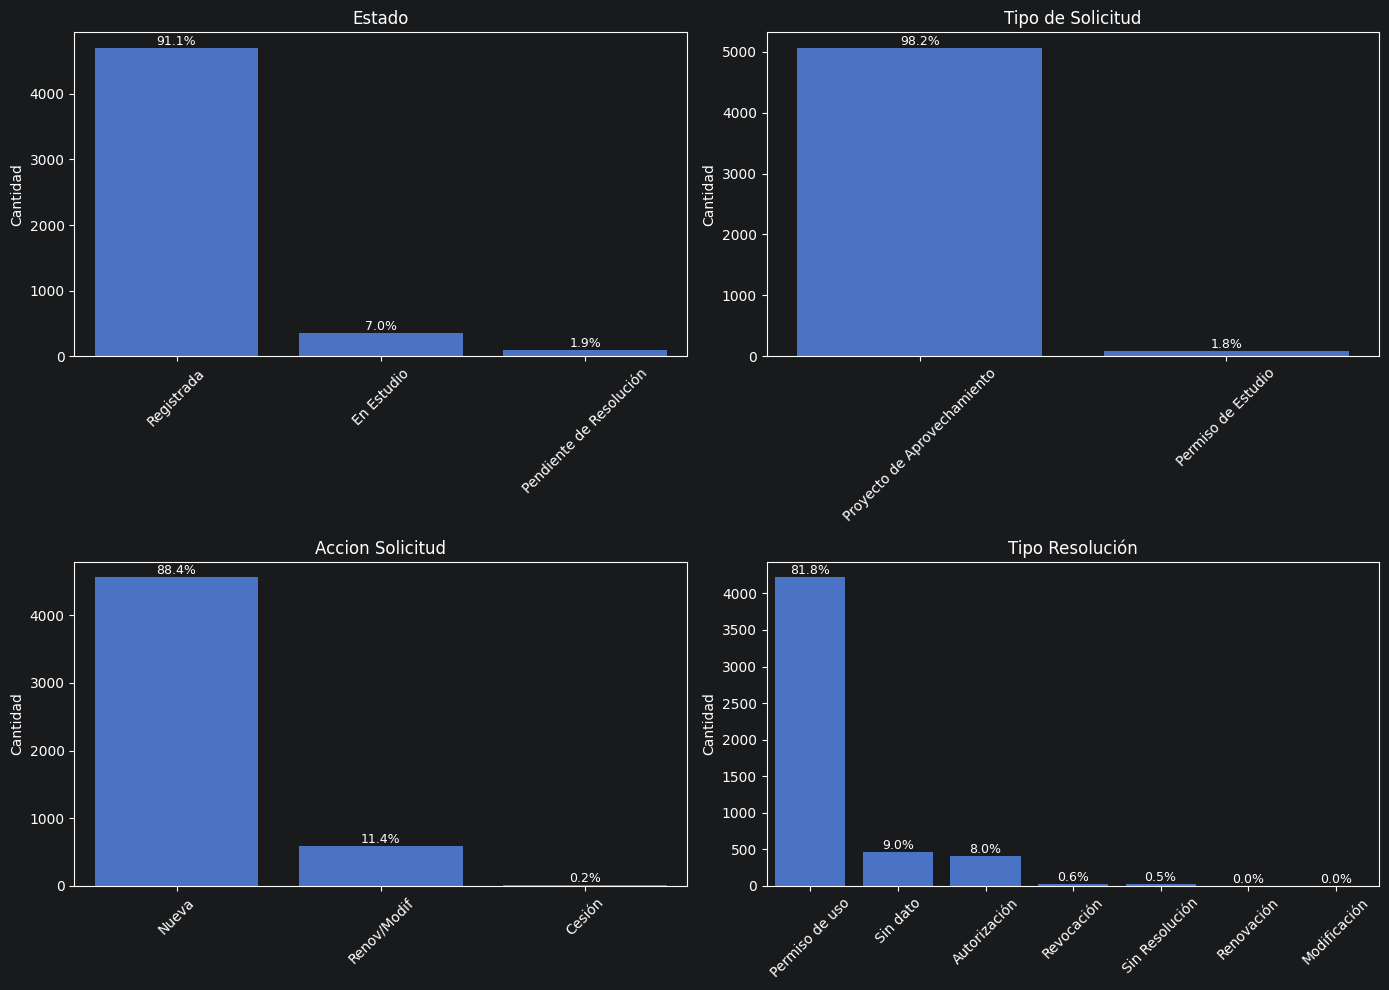

In [50]:
variables = [
    "Estado",
    "Tipo de Solicitud",
    "Accion Solicitud",
    "Tipo Resolución"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variables):

    datos = df[col].fillna("Sin dato").astype(str)

    ax = sns.countplot(
        x=datos,
        order=datos.value_counts().index,
        ax=axes[i]
    )

    total = len(datos)

    for p in ax.patches:
        porcentaje = 100 * p.get_height() / total

        ax.annotate(
            f"{porcentaje:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

De los anteriores gráficos de distribución de frecuencia se observa que:

En la variable Estado hay un marcado predominio de los expedientes Registrados (91,10% del total de los trámites analizados). Los expedientes En Estudio constituyen el 6,98%, y los Pendientes de Resolución representan únicamente el 1,92%. Esta distribución indica que la mayor parte de los trámites incluidos en la base de datos han completado su proceso administrativo.

Respecto al Tipo de Solicitud, los Proyectos de Aprovechamiento representan el 98,18% de los registros, mientras que los Permisos de Estudio alcanzan solamente el 1,82%. Esto evidencia que la gestión analizada se encuentra fuertemente orientada a solicitudes de aprovechamiento efectivo del recurso hídrico.

La variable Acción Solicitud muestra una predominancia de solicitudes Nuevas (88,41%), seguidas por las solicitudes de Renovación o Modificación (11,38%). Las solicitudes por Cesión tienen una participación marginal (0,21%), por lo que constituyen casos excepcionales dentro del conjunto de datos.

En cuanto a la variable Tipo Resolución, presenta como categoría predominante el Permiso de uso, que concentra el 81,82% de los registros. Las Autorizaciones representan el 8,02%, mientras que las categorías Revocación, Sin Resolución, Renovación y Modificación poseen una participación muy reducida. Asimismo, se observa un 9,03% de valores faltantes, los cuales corresponden principalmente a expedientes que aún se encuentran en estado En Estudio o Pendiente de Resolución, por lo que constituyen una situación esperable dentro del proceso administrativo y no un problema de calidad de los datos.

Se observa una marcada concentración de registros en determinadas categorías de las variables analizadas. En particular, los estados "Registrada", los "Proyectos de Aprovechamiento", las solicitudes "Nuevas" y las resoluciones de tipo "Permiso de uso" representan la gran mayoría de los registros. Esta distribución evidencia un comportamiento fuertemente asimétrico de estas variables categóricas, reflejando las características propias de los trámites analizados (mayoritariamente proyectos de aprovechamiento asociados a nuevas solicitudes que culminan con la obtención de un permiso de uso).


Luego de analizadas las variables asociadas al estado administrativo de los trámites, se procede a estudiar las variables Uso y Destino, las cuales permiten caracterizar la finalidad para la que se solicita el aprovechamiento del recurso hídrico.

La variable Uso representa una clasificación general del tipo de aprovechamiento, mientras que la variable Destino proporciona un mayor nivel de detalle sobre la actividad específica a desarrollar. El análisis conjunto de ambas variables permite identificar los principales sectores de demanda de agua y comprender la distribución de los trámites según su finalidad.

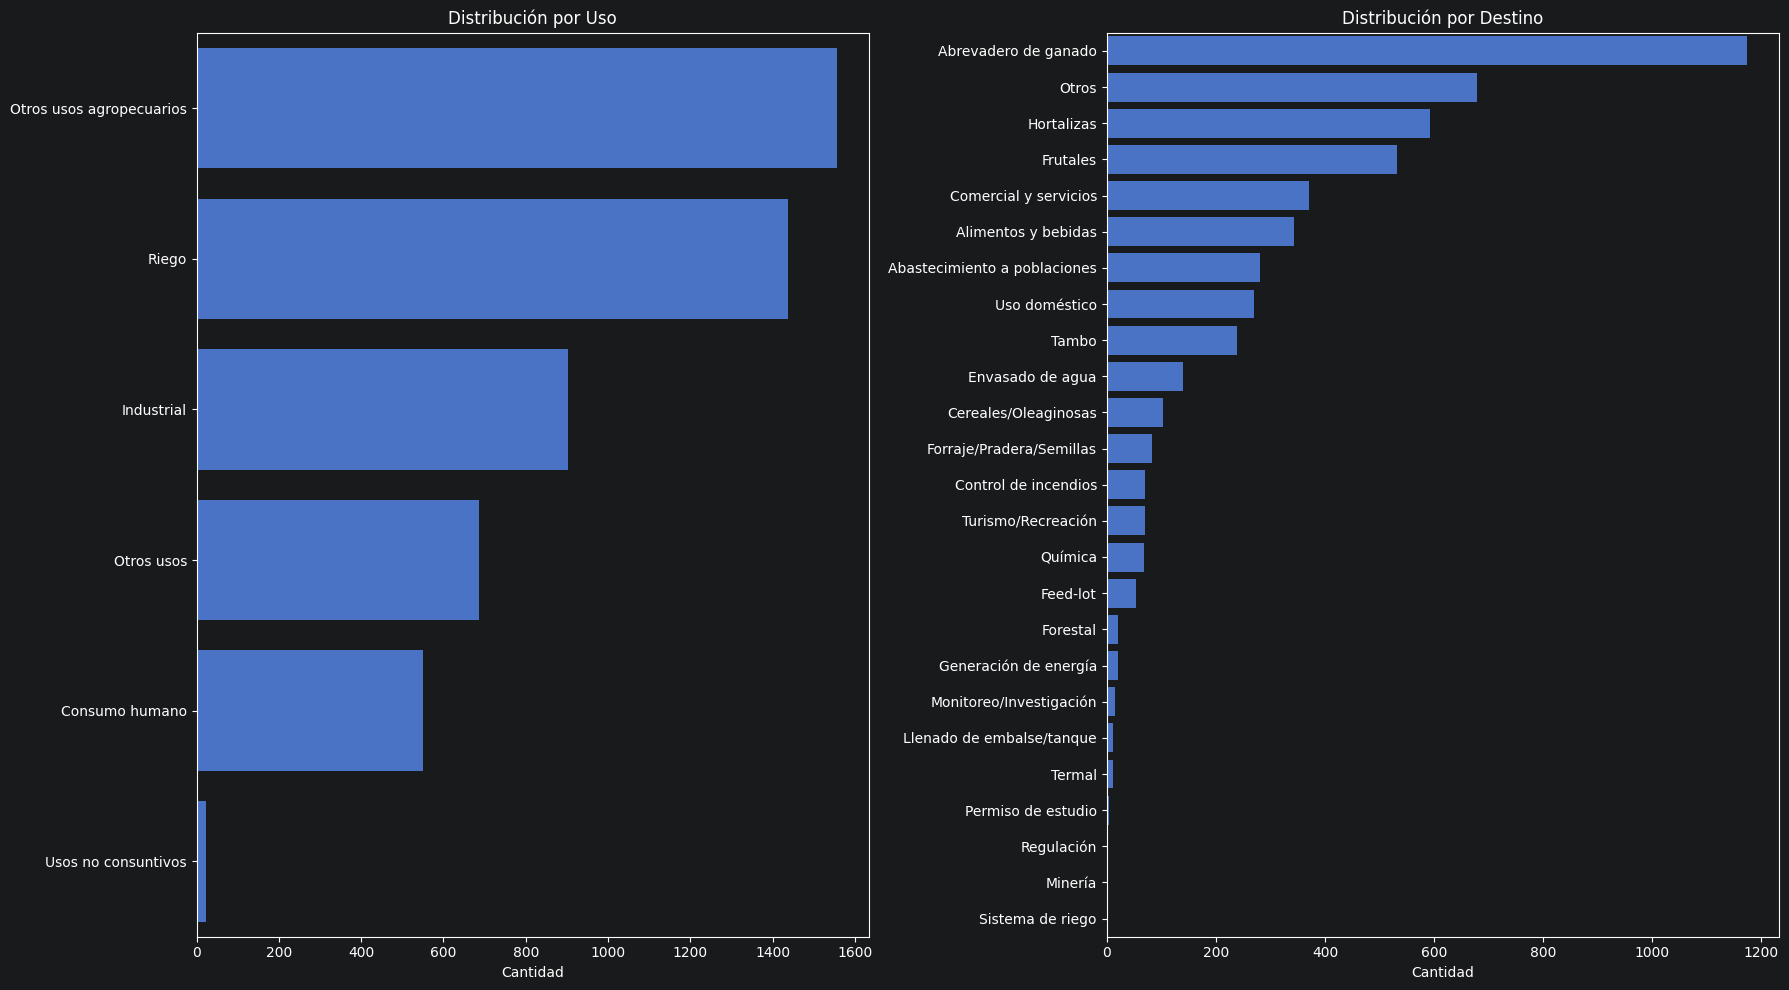

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Uso
sns.countplot(
    data=df,
    y="Uso",
    order=df["Uso"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribución por Uso")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("")

# Destino
sns.countplot(
    data=df,
    y="Destino",
    order=df["Destino"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribución por Destino")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [52]:
tabla_uso = pd.DataFrame({
    "Cantidad": df["Uso"].value_counts(),
    "Porcentaje": round(df["Uso"].value_counts(normalize=True)*100, 2)
})

tabla_destino = pd.DataFrame({
    "Cantidad": df["Destino"].value_counts(),
    "Porcentaje": round(df["Destino"].value_counts(normalize=True)*100, 2)
})

print(tabla_uso.to_string())
print(tabla_destino.to_string())

                          Cantidad  Porcentaje
Uso                                           
Otros usos agropecuarios      1557       30.18
Riego                         1437       27.85
Industrial                     903       17.50
Otros usos                     687       13.32
Consumo humano                 551       10.68
Usos no consuntivos             24        0.47
                              Cantidad  Porcentaje
Destino                                           
Abrevadero de ganado              1174       22.76
Otros                              679       13.16
Hortalizas                         593       11.49
Frutales                           532       10.31
Comercial y servicios              370        7.17
Alimentos y bebidas                344        6.67
Abastecimiento a poblaciones       281        5.45
Uso doméstico                      270        5.23
Tambo                              238        4.61
Envasado de agua                   140        2.71
Cereales/Ole

De los gráficos y tablas anteriores se observa que:

En relación con la variable Uso, se observa que los trámites se concentran principalmente en las categorías Otros usos agropecuarios (30,18%) y Riego (27,85%), que en conjunto representan más de la mitad de los registros analizados. En segundo término se encuentran los usos Industriales (17,50%) y Otros usos (13,32%), mientras que el Consumo humano representa el 10,68% de los trámites. Los Usos no consuntivos poseen una participación marginal, alcanzando únicamente el 0,47% del total.

El análisis de la variable Destino permite observar con mayor detalle la finalidad específica de los aprovechamientos solicitados. La categoría más frecuente corresponde a Abrevadero de ganado (22,76%), seguida por Otros (13,16%), Hortalizas (11,49%) y Frutales (10,31%). También presentan una participación relevante los destinos vinculados a Comercial y servicios (7,17%), Alimentos y bebidas (6,67%), Abastecimiento a poblaciones (5,45%), Uso doméstico (5,23%) y Tambo (4,61%).

Los resultados evidencian un predominio de trámites asociados a actividades agropecuarias, particularmente aquellas vinculadas al riego, la producción hortifrutícola y el abastecimiento de agua para ganado. Asimismo, se observa una participación significativa de actividades industriales, comerciales y de abastecimiento humano, reflejando la diversidad de usos y destinos del recurso hídrico gestionados por el organismo.

Para finalizar con las variables categóricas se analizan Regional y Departamento, las cuales permiten caracterizar la distribución geográfica de los trámites incluidos en el conjunto de datos.

La variable Regional identifica la oficina regional responsable de la gestión de los expedientes, mientras que la variable Departamento indica la ubicación geográfica asociada a la solicitud. El análisis conjunto de ambas variables permite identificar la concentración territorial de los trámites y evaluar la distribución geográfica de la demanda de permisos de uso de aguas públicas.

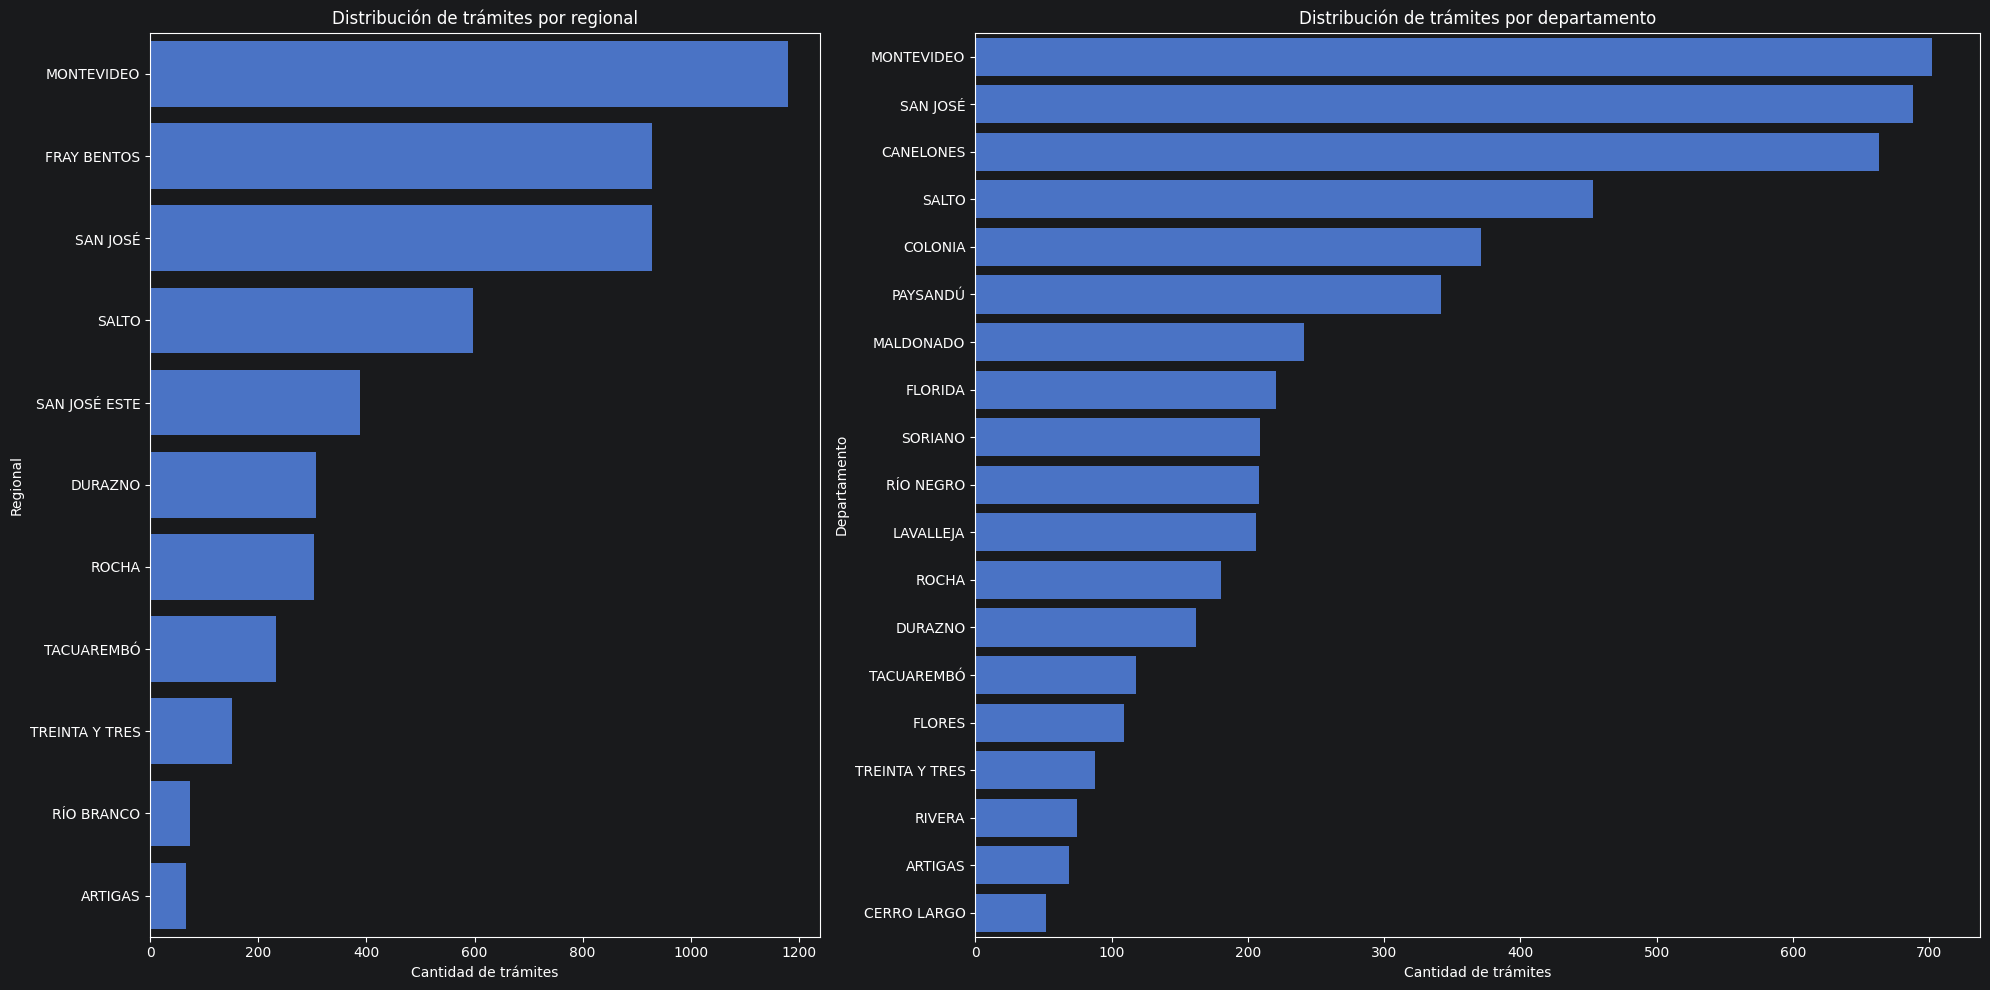

In [53]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 10),
    gridspec_kw={'width_ratios': [1, 1.5]}
)

# Regional
sns.countplot(
    data=df,
    y="Regional",
    order=df["Regional"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribución de trámites por regional")
axes[0].set_xlabel("Cantidad de trámites")
axes[0].set_ylabel("Regional")

# Departamento
sns.countplot(
    data=df,
    y="Departamento",
    order=df["Departamento"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribución de trámites por departamento")
axes[1].set_xlabel("Cantidad de trámites")
axes[1].set_ylabel("Departamento")

plt.tight_layout()
plt.show()

In [54]:
tabla_regional = pd.DataFrame({
    "Cantidad": df["Regional"].value_counts(),
    "Porcentaje": round(df["Regional"].value_counts(normalize=True)*100,2)
})

print(tabla_regional.to_string())

                Cantidad  Porcentaje
Regional                            
MONTEVIDEO          1180       22.88
FRAY BENTOS          929       18.01
SAN JOSÉ             929       18.01
SALTO                598       11.60
SAN JOSÉ ESTE        388        7.52
DURAZNO              306        5.93
ROCHA                303        5.88
TACUAREMBÓ           233        4.52
TREINTA Y TRES       151        2.93
RÍO BRANCO            74        1.43
ARTIGAS               66        1.28


In [55]:
tabla_departamento = pd.DataFrame({
    "Cantidad": df["Departamento"].value_counts(),
    "Porcentaje": round(df["Departamento"].value_counts(normalize=True)*100,2)
})

print(tabla_departamento.to_string())

                Cantidad  Porcentaje
Departamento                        
MONTEVIDEO           702       13.61
SAN JOSÉ             688       13.34
CANELONES            663       12.86
SALTO                453        8.78
COLONIA              371        7.19
PAYSANDÚ             342        6.63
MALDONADO            241        4.67
FLORIDA              221        4.29
SORIANO              209        4.05
RÍO NEGRO            208        4.03
LAVALLEJA            206        3.99
ROCHA                180        3.49
DURAZNO              162        3.14
TACUAREMBÓ           118        2.29
FLORES               109        2.11
TREINTA Y TRES        88        1.71
RIVERA                75        1.45
ARTIGAS               69        1.34
CERRO LARGO           52        1.01


En relación con la variable Regional, se observa una marcada concentración de expedientes en las oficinas de Montevideo (22,88%), Fray Bentos (18,01%) y San José (18,01%). En conjunto, estas tres regionales gestionan aproximadamente el 59% de los trámites incluidos en la base de datos. Las regionales de Salto (11,60%), San José Este (7,52%), Durazno (5,93%) y Rocha (5,88%) presentan una participación intermedia, mientras que Tacuarembó, Treinta y Tres, Río Branco y Artigas registran las menores cantidades de expedientes.

Por su parte, la variable Departamento muestra una distribución más diversificada. Los departamentos con mayor cantidad de trámites son Montevideo (13,61%), San José (13,34%) y Canelones (12,86%), seguidos por Salto (8,78%), Colonia (7,19%) y Paysandú (6,63%). En conjunto, estos seis departamentos concentran más del 60% de los registros analizados.

La comparación entre ambas variables permite observar que la concentración de trámites es más pronunciada a nivel de regionales que a nivel departamental, lo que resulta consistente con la estructura administrativa del organismo, donde una misma oficina regional puede gestionar expedientes correspondientes a varios departamentos.

En términos generales, los resultados evidencian una distribución territorial heterogénea de los trámites, con una mayor concentración en los departamentos y regionales ubicados en el sur y litoral oeste del país. Esta situación podría estar asociada tanto a diferencias en la demanda de uso del recurso hídrico como a la distribución geográfica de las actividades productivas y de la población.

b) Análisis univariante de variables numéricas

Luego de finalizado el análisis de las variables categóricas, se procede al estudio de las variables numéricas.

Dentro de este grupo se identifican las variables Caudal, Volumen, Horas x Año, Profundidad, Diámetro, Caudal Ensayado, Nivel Estático y Nivel Dinámico, las cuales aportan información relevante sobre las características hidráulicas de las captaciones y el uso autorizado del recurso hídrico.

Por otra parte, si bien las variables Latitud, Longitud, Mes Inicio, Mes Final, Id Solicitud y Sección y localidad catastral tienen formato numérico, no se consideran de interés para el análisis descriptivo univariante. En particular, Id Solicitud corresponde a un identificador administrativo sin significado analítico, Sección y localidad catastral es un código de referencia territorial. Asimismo, las variables Latitud y Longitud adquieren mayor relevancia en análisis espaciales, y las variables Mes Inicio y Mes Final resultan más apropiadas para estudios temporales específicos que para un análisis descriptivo de magnitudes físicas.

El análisis numérico se centrará en aquellas variables que describen las características técnicas de los aprovechamientos y presentan mayor potencial para aportar información relevante sobre los permisos de uso de aguas públicas.

In [56]:
variables_numericas_eda = [
    "Caudal",
    "Volumen",
    "Horas x Año",
    "profundidad",
    "Diámetro",
    "Caudal Ensayado",
    "Nivel Estático",
    "Nivel Dinámico"
]

df[variables_numericas_eda].describe().T

,count,mean,std,min,25%,50%,75%,max
Caudal,5113.0,30.760613,710.006984,0.00,2.50,5.0,10.0,27000.0
Volumen,5127.0,31038.216690,67665.995348,0.00,5184.00,12960.0,30240.0,1814400.0
Horas x Año,5121.0,3128.130443,1866.384298,1.00,1600.00,2880.0,4320.0,9000.0
profundidad,5115.0,52.235572,65.214100,0.00,35.00,45.0,60.0,1494.0
Diámetro,5095.0,173.100473,225.025282,0.00,150.00,160.0,200.0,5000.0
Caudal Ensayado,4972.0,16.159835,245.645150,0.00,2.80,5.5,12.0,15000.0
Nivel Estático,4808.0,10.636425,19.967036,-9.55,4.62,8.7,14.0,1234.0
Nivel Dinámico,4655.0,26.939966,23.805388,-39.62,16.00,24.0,35.0,1234.0


Del anterior análsis se observa una importante variabilidad en los valores registrados, evidenciada por las diferencias entre los valores mínimos, máximos y cuartiles de las distintas variables.

Varias de las variables presentan diferencias significativas entre la media y la mediana. Este comportamiento es particularmente visible en las variables Caudal, Volumen, Profundidad y Caudal Ensayado, donde la media resulta considerablemente superior a la mediana. Esta situación sugiere la existencia de distribuciones asimétricas, caracterizadas por una gran concentración de observaciones en valores relativamente bajos y un número reducido de registros con valores muy elevados.

Por otra parte, los valores máximos observados en algunas variables son considerablemente superiores al tercer cuartil, lo que constituye un indicio de la presencia de valores extremos. Por ejemplo, el Caudal presenta una mediana de 5 m³/h y un tercer cuartil de 10 m³/h, mientras que el valor máximo registrado alcanza los 27.000 m³/h. Un comportamiento similar se observa en las variables Volumen, Profundidad, Diámetro y Caudal Ensayado.

En las variables Nivel Estático y Nivel Dinámico también se identifican valores extremos y la presencia de registros negativos.

A continuación se complementa el análisis descriptivo mediante representaciones gráficas de las distribuciones con el objetivo de comprender mejor el comportamiento de cada variable y su impacto potencial en los análisis posteriores.

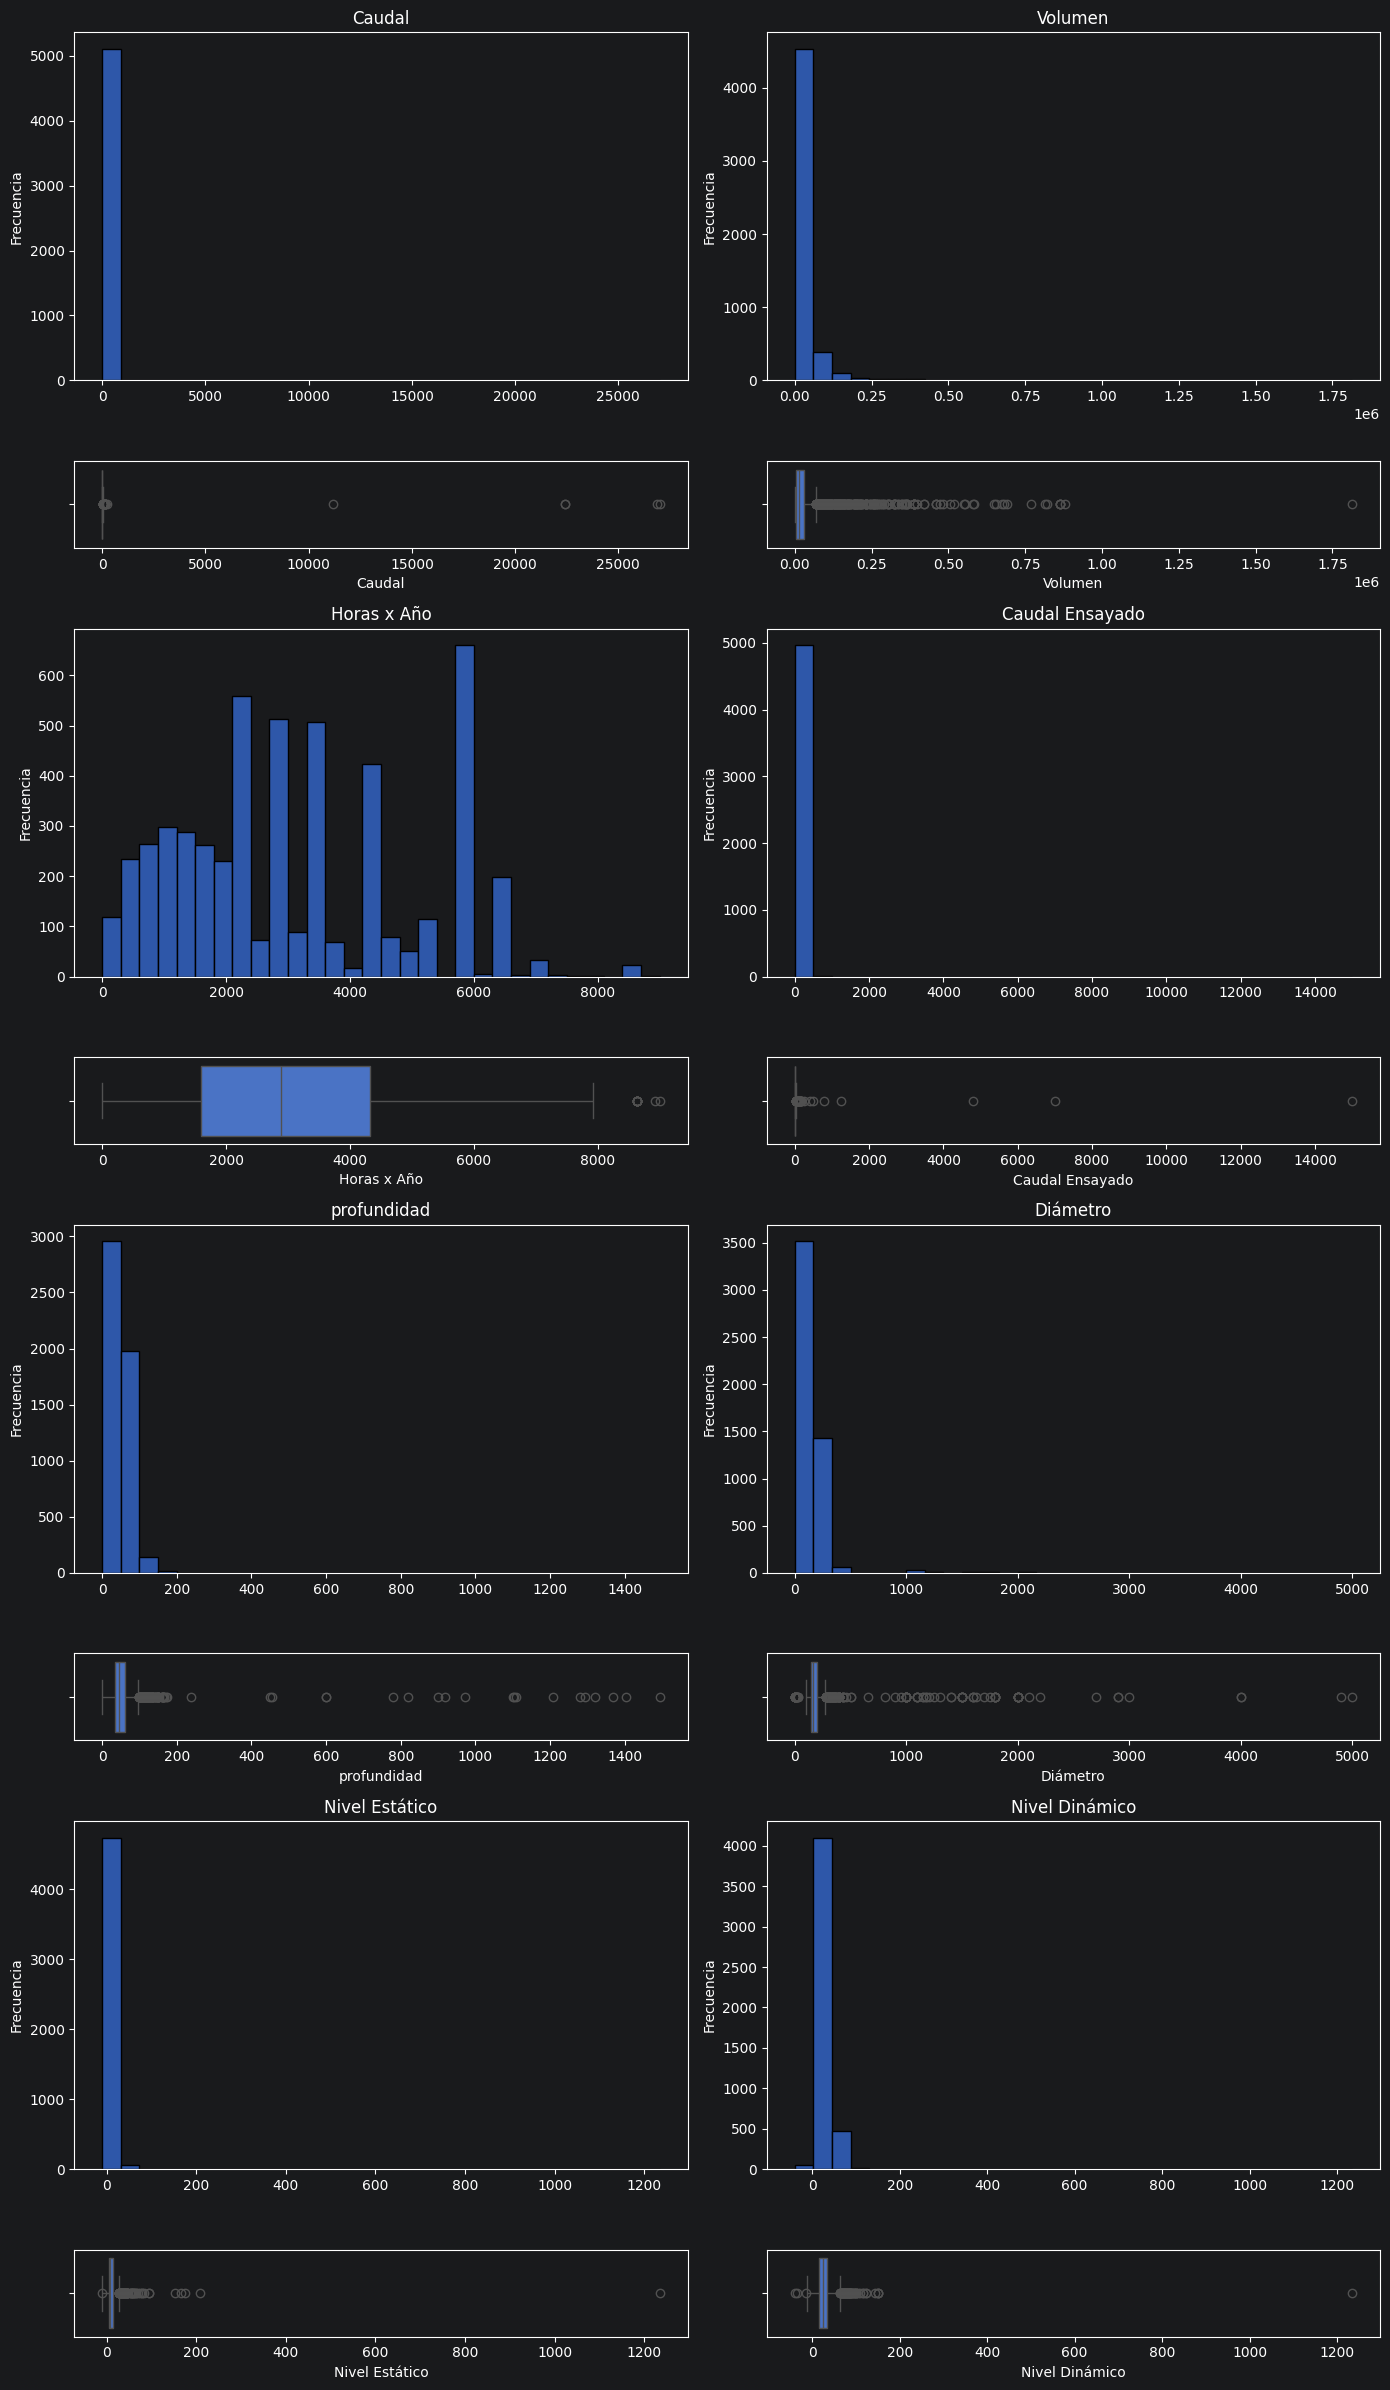

In [57]:
variables_numericas_eda = [
    "Caudal",
    "Volumen",

    "Horas x Año",
    "Caudal Ensayado",

    "profundidad",
    "Diámetro",

    "Nivel Estático",
    "Nivel Dinámico"
]

fig, axes = plt.subplots(
    8, 2,
    figsize=(14, 24),
    gridspec_kw={"height_ratios": [4, 1, 4, 1, 4, 1, 4, 1]}
)

for i in range(0, len(variables_numericas_eda), 2):

    fila = (i // 2) * 2

    # Variable izquierda
    var1 = variables_numericas_eda[i]

    sns.histplot(
        data=df,
        x=var1,
        bins=30,
        ax=axes[fila, 0]
    )

    axes[fila, 0].set_title(var1)
    axes[fila, 0].set_xlabel("")
    axes[fila, 0].set_ylabel("Frecuencia")

    sns.boxplot(
        data=df,
        x=var1,
        ax=axes[fila + 1, 0]
    )

    axes[fila + 1, 0].set_xlabel(var1)

    # Variable derecha
    var2 = variables_numericas_eda[i + 1]

    sns.histplot(
        data=df,
        x=var2,
        bins=30,
        ax=axes[fila, 1]
    )

    axes[fila, 1].set_title(var2)
    axes[fila, 1].set_xlabel("")
    axes[fila, 1].set_ylabel("Frecuencia")

    sns.boxplot(
        data=df,
        x=var2,
        ax=axes[fila + 1, 1]
    )

    axes[fila + 1, 1].set_xlabel(var2)

plt.tight_layout()
plt.show()

Los histogramas y diagramas de caja permiten complementar la información obtenida a partir de las estadísticas descriptivas. En términos generales, la mayoría de las variables presentan distribuciones asimétricas hacia la derecha, con una alta concentración de observaciones en valores bajos y un número reducido de registros con valores significativamente superiores al resto.

Esta situación se refleja en la presencia de numerosos valores atípicos identificados en los diagramas de caja, particularmente en las variables Caudal, Volumen, Caudal Ensayado, Profundidad, Diámetro, Nivel Estático y Nivel Dinámico. Asimismo, la influencia de estos valores extremos dificulta la visualización detallada de la distribución principal de algunas variables en los histogramas.

Por otra parte, la variable Horas x Año presenta una distribución más homogénea y una menor influencia de valores extremos en comparación con el resto de las variables analizadas.

Dado que estas variables describen características técnicas de los aprovechamientos de aguas y de las obras asociadas a los permisos, y considerando que el objetivo principal del presente trabajo se centra en el análisis de la gestión de los trámites y sus tiempos de tramitación, no se profundiza en la validación individual de los valores atípicos identificados. No obstante, la revisión realizada permitió verificar la ausencia de inconsistencias generalizadas que comprometan la calidad global de la información disponible para el análisis.

Una vez finalizada la revisión de las variables originales del conjunto de datos, se procede a la creación de una nueva variable derivada denominada Tiempo de Tramitación, con el propósito de cuantificar la duración del proceso administrativo asociado a cada expediente.

Esta variable se calcula a partir de la diferencia entre la Fecha de Solicitud y la Fecha de Resolución, representando el tiempo transcurrido entre el ingreso del trámite y la emisión de la resolución correspondiente. Dado que el objetivo principal del presente análisis es evaluar aspectos vinculados a la gestión de los expedientes y los tiempos de procesamiento, esta variable constituye uno de los principales indicadores para el estudio de la eficiencia administrativa.

Con el fin de facilitar la interpretación de los resultados, el tiempo de tramitación se expresa en meses.

In [58]:
df["Tiempo de Tramitación"] = (
    (df["Fecha de Resolución"] - df["Fecha de Solicitud"]).dt.days
    / 30.44
)

In [59]:
df["Tiempo de Tramitación"].describe()

count    4698.000000
mean        5.455959
std        19.901829
min      -113.764783
25%         1.084100
50%         3.580815
75%         7.621551
max       206.438896
Name: Tiempo de Tramitación, dtype: float64

En los datos anteriores se evidencia la presencia de valores negativos para el Tiempo de tramitación, (-113,76 meses). Esta situación no resulta consistente con el proceso administrativo analizado, ya que implicaría la existencia de resoluciones emitidas con anterioridad a la fecha de presentación de la solicitud del trámite.

Por este motivo, se realiza una revisión específica de los registros con tiempos de tramitación negativos, con el objetivo de identificar posibles inconsistencias y evaluar la necesidad de aplicar criterios de depuración antes de continuar con el análisis de los tiempos de gestión.

In [60]:
(df["Tiempo de Tramitación"] < 0).sum()

np.int64(684)

In [61]:
df.loc[
    df["Tiempo de Tramitación"] < 0,
    "Tiempo de Tramitación"
].describe()

count    684.000000
mean     -15.333203
std       12.850887
min     -113.764783
25%      -26.412615
50%      -20.006570
75%       -2.135348
max       -0.032852
Name: Tiempo de Tramitación, dtype: float64

In [62]:
df.loc[
    df["Tiempo de Tramitación"] < 0,
    [
        "Fecha de Solicitud",
        "Fecha de Resolución",
        "Estado",
        "Tiempo de Tramitación"
    ]
].head(10)

,Fecha de Solicitud,Fecha de Resolución,Estado,Tiempo de Tramitación
58,2005-05-08,2001-12-05,Registrada,-41.064389
161,2005-09-05,2002-10-02,Registrada,-35.118265
275,2004-08-11,1995-02-17,Registrada,-113.764783
277,2004-09-22,1997-04-04,Registrada,-89.618922
291,2005-10-07,2005-01-11,Registrada,-8.837057
303,2006-04-06,2006-03-20,Registrada,-0.558476
658,2013-05-20,2013-05-17,Registrada,-0.098555
659,2013-05-20,2013-05-17,Registrada,-0.098555
660,2013-05-20,2013-05-17,Registrada,-0.098555
661,2013-05-21,2013-05-17,Registrada,-0.131406


In [63]:
df.loc[
    df["Tiempo de Tramitación"] < 0,
    "Estado"
].value_counts(dropna=False)

Estado
Registrada    684
Name: count, dtype: int64

In [64]:
(
    df.loc[
        df["Tiempo de Tramitación"] < 0,
        "Estado"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Estado
Registrada    100.0
Name: proportion, dtype: float64

In [65]:
df.loc[
    df["Tiempo de Tramitación"] < 0,
    "Tipo Resolución"
].value_counts()

Tipo Resolución
Permiso de uso    680
Autorización        4
Name: count, dtype: int64

In [66]:
(
    df.loc[df["Tiempo de Tramitación"] < 0,
           "Tipo Resolución"]
    .value_counts(normalize=True)
    * 100
).round(2)

Tipo Resolución
Permiso de uso    99.42
Autorización       0.58
Name: proportion, dtype: float64

La revisión de los registros con tiempo de tramitación negativo muestra que todos los expedientes se encuentran en estado Registrada, lo que indica que corresponden a trámites efectivamente resueltos.

Asimismo, se observó que 680 de los 684 registros (99,4%) pertenecen a la categoría Permiso de uso dentro de la variable Tipo Resolución, evidenciando que no se trata de errores aislados de carga sino de una situación sistemática asociada a un subconjunto específico de expedientes.

La inspección de las fechas registradas permite constatar que, en estos casos, la fecha de resolución aparece cronológicamente anterior a la fecha de solicitud. Con el objetivo de evaluar esta situación, se realiza un cálculo alternativo del tiempo de tramitación utilizando la diferencia inversa entre ambas fechas. Los resultados obtenidos muestran tiempos de tramitación coherentes desde el punto de vista administrativo.

Considerando la evidencia observada, se decide corregir el cálculo del tiempo de tramitación para estos expedientes mediante la inversión de las fechas utilizadas. Esta decisión permite recuperar información potencialmente válida y evitar la exclusión de un número significativo de registros del análisis.

(Antes de aplicar la corrección sobre los registros identificados, se genera una copia de seguridad de la base de datos original. De esta forma, ante cualquier necesidad de validación o revisión posterior, es posible recuperar el estado original de la base sin pérdida de información).

In [67]:
df_backup = df.copy()

In [68]:
# Identificar registros con tiempo de tramitación negativo
mask = df["Tiempo de Tramitación"] < 0

print("Registros a corregir:", mask.sum())

# Intercambiar Fecha de Solicitud y Fecha de Resolución
df.loc[mask, ["Fecha de Solicitud", "Fecha de Resolución"]] = (
    df.loc[mask, ["Fecha de Resolución", "Fecha de Solicitud"]].values
)

# Recalcular Tiempo de Tramitación en meses
df["Tiempo de Tramitación"] = (
    (df["Fecha de Resolución"] - df["Fecha de Solicitud"]).dt.days / 30.44
)

# Verificar
print("Tiempos negativos restantes:", (df["Tiempo de Tramitación"] < 0).sum())
print("Tiempos sin calcular:", df["Tiempo de Tramitación"].isna().sum())
print("Dimensión de la base:", df.shape)

Registros a corregir: 684
Tiempos negativos restantes: 0
Tiempos sin calcular: 461
Dimensión de la base: (5159, 29)


In [69]:
(df["Tiempo de Tramitación"] < 0).sum()

np.int64(0)

In [70]:
df["Tiempo de Tramitación"].isna().sum()

np.int64(461)

In [71]:
pd.DataFrame({
    "Concepto": [
        "Expedientes totales",
        "Sin fecha de resolución",
        "Con tiempo de tramitación calculable"
    ],
    "Cantidad": [
        len(df),
        df["Tiempo de Tramitación"].isna().sum(),
        df["Tiempo de Tramitación"].notna().sum()
    ]
})

,Concepto,Cantidad
0,Expedientes totales,5159
1,Sin fecha de resolución,461
2,Con tiempo de tramitación calculable,4698


In [72]:
df.shape

(5159, 29)

Luego de realizada la corrección se verifica que la corrección aplicada no modifica la cantidad de registros de la base de datos, manteniéndose los 5159 expedientes originales. Además, se verifica la existencia de valores faltantes en la variable Tiempo de Tramitación. Se identifican 461 expedientes sin tiempo de tramitación calculable debido a la ausencia de fecha de resolución. Estos registros corresponden a trámites que aún no cuentan con una resolución registrada y, por lo tanto, no permiten determinar la duración completa del proceso administrativo. Asimismo, se comprueba la ausencia de tiempos de tramitación negativos luego de la corrección realizada.

Finalizada esta etapa, se obtiene una base de datos consistente para el estudio de los tiempos de gestión de los expedientes y para el desarrollo de los análisis posteriores.

A continuación se realiza el análisis de la variable Tiempo de Tramitación.

In [73]:
df[["Tiempo de Tramitación"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Tiempo de Tramitación,4698.0,9.9208,18.094569,0.0,2.332457,4.599212,10.372865,206.438896


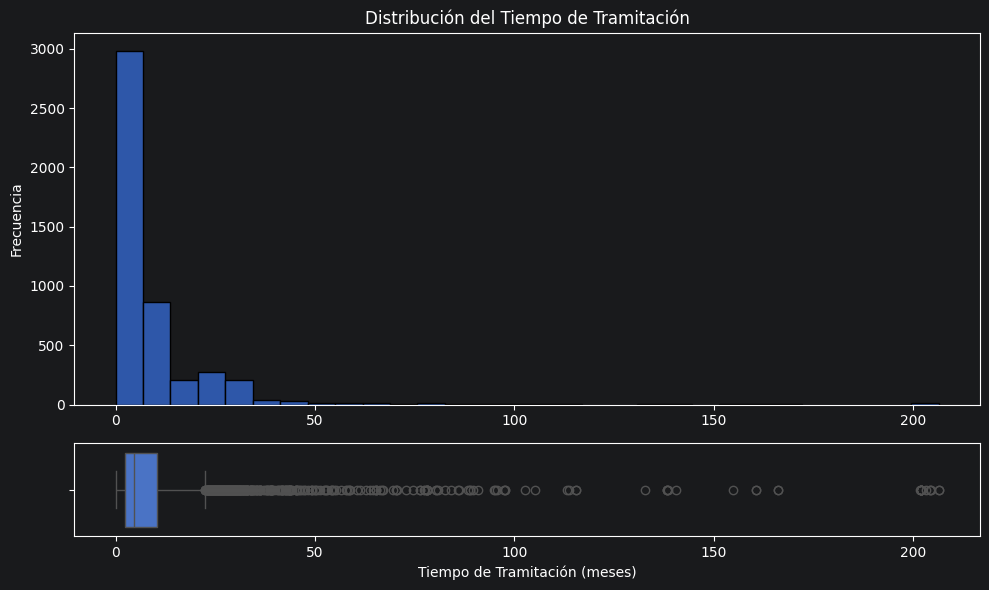

In [74]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [4, 1]}
)

# Histograma
sns.histplot(
    data=df,
    x="Tiempo de Tramitación",
    bins=30,
    ax=ax1
)

ax1.set_title("Distribución del Tiempo de Tramitación")
ax1.set_xlabel("")
ax1.set_ylabel("Frecuencia")

# Boxplot
sns.boxplot(
    data=df,
    x="Tiempo de Tramitación",
    ax=ax2
)

ax2.set_xlabel("Tiempo de Tramitación (meses)")

plt.tight_layout()
plt.show()

Se observa que la variable Tiempo de tramitación presenta una distribución asimétrica hacia la derecha, caracterizada por una elevada concentración de expedientes con tiempos de resolución relativamente bajos y una cola larga compuesta por trámites de duración considerablemente mayor.

Se observa que la mayor parte de los expedientes se resuelve dentro de los primeros meses posteriores a la presentación de la solicitud. Esta situación resulta consistente con la mediana de 4,6 meses y con el hecho de que el 75% de los trámites presenta tiempos de tramitación inferiores a 10,4 meses.

Por otra parte, el diagrama de caja evidencia la presencia de numerosos valores atípicos, correspondientes a expedientes con tiempos de tramitación significativamente superiores al comportamiento habitual. Algunos casos alcanzan duraciones superiores a 200 meses, generando una importante dispersión en los datos.

La presencia de estos expedientes explica la diferencia observada entre la media (9,9 meses) y la mediana (4,6 meses), indicando que el tiempo de tramitación promedio se encuentra influenciado por un conjunto reducido de trámites de muy larga duración. En consecuencia, la mediana constituye una medida más representativa del tiempo de resolución típico de los expedientes analizados.

c) Análisis multivariante

A continuación se realiza un análisis multivariante con el propósito de explorar posibles relaciones entre las características de los expedientes y los tiempos de gestión observados. En primer lugar, se analizan relaciones entre variables numéricas

In [75]:
variables_numericas = [
    "Tiempo de Tramitación",
    "Caudal",
    "Volumen",
    "Horas x Año",
    "profundidad",
    "Diámetro",
    "Caudal Ensayado",
    "Nivel Estático",
    "Nivel Dinámico"
]

In [76]:
corr = df[variables_numericas].corr()

corr.round(2)

,Tiempo de Tramitación,Caudal,Volumen,Horas x Año,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico
Tiempo de Tramitación,1.00,0.00,0.01,0.00,-0.03,-0.06,-0.01,-0.02,-0.00
Caudal,0.00,1.00,0.06,-0.01,0.01,-0.00,0.00,0.00,-0.01
Volumen,0.01,0.06,1.00,0.31,0.47,0.00,0.05,0.05,-0.01
Horas x Año,0.00,-0.01,0.31,1.00,0.08,-0.00,0.00,-0.02,-0.04
profundidad,-0.03,0.01,0.47,0.08,1.00,-0.03,0.03,0.10,0.20
Diámetro,-0.06,-0.00,0.00,-0.00,-0.03,1.00,0.01,-0.02,-0.09
Caudal Ensayado,-0.01,0.00,0.05,0.00,0.03,0.01,1.00,0.06,0.05
Nivel Estático,-0.02,0.00,0.05,-0.02,0.10,-0.02,0.06,1.00,0.77
Nivel Dinámico,-0.00,-0.01,-0.01,-0.04,0.20,-0.09,0.05,0.77,1.00


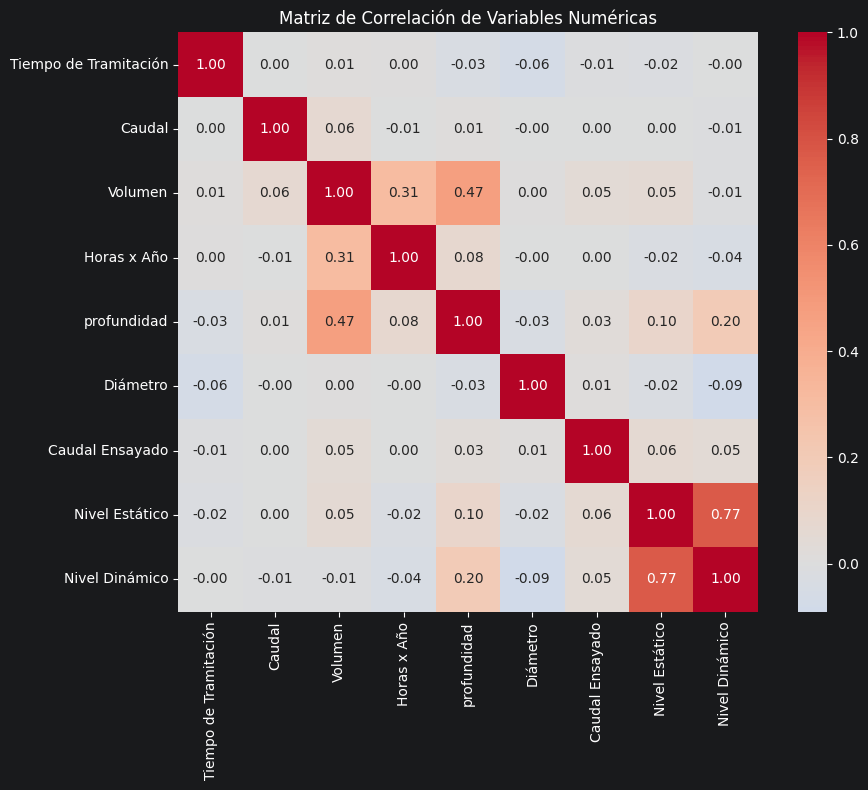

In [77]:
corr = df[variables_numericas].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matriz de Correlación de Variables Numéricas")
plt.tight_layout()
plt.show()

In [78]:
corr["Tiempo de Tramitación"].sort_values(ascending=False)

Tiempo de Tramitación    1.000000
Volumen                  0.011469
Horas x Año              0.003801
Caudal                   0.002667
Nivel Dinámico          -0.002213
Caudal Ensayado         -0.008518
Nivel Estático          -0.018865
profundidad             -0.032946
Diámetro                -0.061331
Name: Tiempo de Tramitación, dtype: float64

La matriz de correlación muestra la ausencia de relaciones lineales relevantes entre el Tiempo de Tramitación y las variables técnicas incluidas en el conjunto de datos. Todos los coeficientes de correlación asociados a esta variable presentan magnitudes muy próximas a cero, indicando que las características físicas de los aprovechamientos no influyen de forma significativa en la duración de los expedientes.

Por otra parte, sí se observan algunas asociaciones entre variables técnicas. Se puede destacar la correlación entre Nivel Estático y Nivel Dinámico (r = 0,77), relación que resulta consistente con la naturaleza de las variables analizadas.

En conclusión, los resultados sugieren que las diferencias observadas en los tiempos de tramitación no responen a las características técnicas de los aprovechamientos de agua.

A continuación se aborda el estudio conjunto de variables numéricas y categóricas, utilizando como variable de interés el Tiempo de Tramitación y evaluando su comportamiento en función de distintas características administrativas y territoriales de los expedientes.

En primer lugar se analiza la relación entre la variable Tiempo de Tramitación y la variable Regional. Dado que la distribución del tiempo de tramitación presenta una marcada asimetría y numerosos valores extremos, la mediana constituye una medida especialmente relevante para la comparación entre regionales, al representar de forma más adecuada el comportamiento habitual de los expedientes.

In [79]:
regional_tiempo = (
    df
    .groupby("Regional")["Tiempo de Tramitación"]
    .agg(
        Cantidad="count",
        Promedio="mean",
        Mediana="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .round(2)
    .sort_values("Mediana", ascending=False)
)

display(("Tiempo de Tramitación por Regional"))
display(regional_tiempo)

'Tiempo de Tramitación por Regional'

,Cantidad,Promedio,Mediana,Q1,Q3
Regional,,,,,
RÍO BRANCO,64,14.21,7.49,3.25,28.52
SALTO,523,10.17,6.87,4.17,11.88
FRAY BENTOS,857,11.19,5.22,2.50,10.32
TREINTA Y TRES,140,11.11,5.12,3.18,24.62
ARTIGAS,61,14.22,4.76,2.00,12.78
SAN JOSÉ,854,8.89,4.50,2.33,10.48
TACUAREMBÓ,198,9.98,4.48,1.84,11.88
ROCHA,254,13.73,4.30,2.09,11.59
SAN JOSÉ ESTE,357,12.60,3.88,2.33,12.39


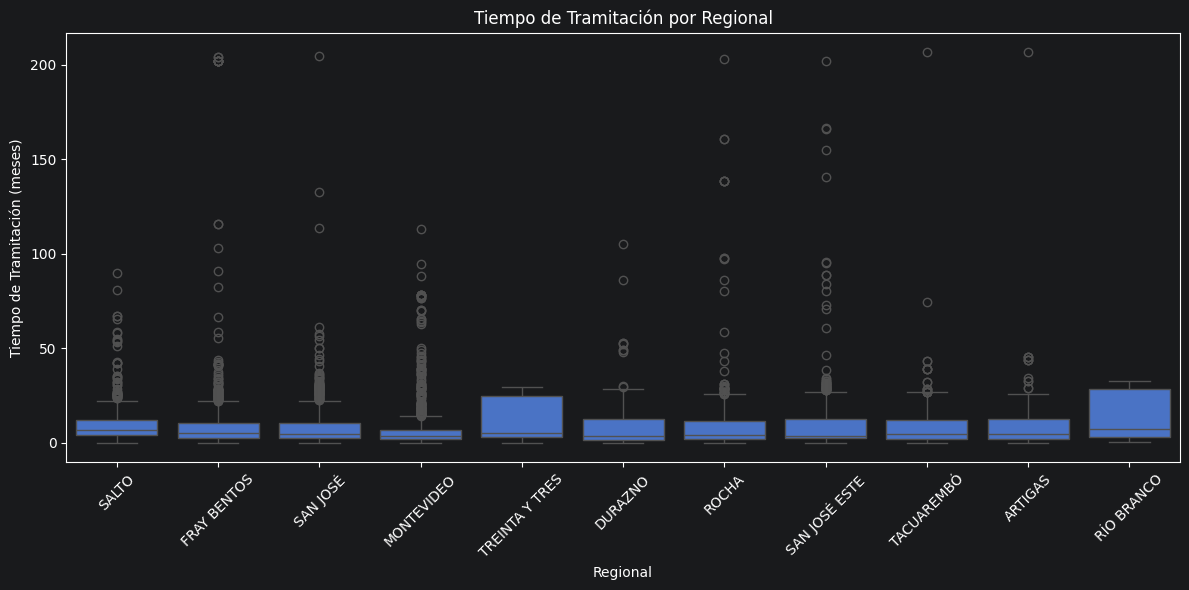

In [80]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Regional",
    y="Tiempo de Tramitación"
)

plt.xticks(rotation=45)
plt.xlabel("Regional")
plt.ylabel("Tiempo de Tramitación (meses)")
plt.title("Tiempo de Tramitación por Regional")

plt.tight_layout()
plt.show()

La comparación de los tiempos de tramitación entre regionales evidencia diferencias relevantes en la duración de los expedientes. Considerando la mediana como medida principal de comparación, se observa que las regionales de Río Branco y Salto presentan los mayores tiempos típicos de tramitación, con valores de 7,5 y 6,9 meses respectivamente.

Por el contrario, las regionales de Montevideo y Durazno registran las menores medianas, situándose en torno a los 4 meses. Estos resultados sugieren la existencia de diferencias en los tiempos de gestión entre oficinas regionales.

Asimismo, algunas regionales presentan una elevada dispersión en los tiempos de tramitación. En particular, Río Branco y Treinta y Tres exhiben rangos intercuartílicos considerablemente superiores al resto, lo que indica una mayor heterogeneidad en la duración de los expedientes gestionados.

El diagrama de caja permite complementar el análisis descriptivo de los tiempos de tramitación por regional. Se observa que todas las regionales presentan distribuciones asimétricas hacia la derecha y una cantidad importante de valores atípicos, evidenciando la existencia de expedientes con tiempos de resolución significativamente superiores al comportamiento habitual.

Las regionales de Río Branco y Salto presentan las mayores medianas de tiempo de tramitación, mientras que Montevideo y Durazno exhiben los menores tiempos típicos de resolución. Asimismo, algunas oficinas, como Río Branco, Treinta y Tres y San José Este, muestran una mayor dispersión en los tiempos de gestión, reflejada en rangos intercuartílicos más amplios.

No obstante, se observa una superposición considerable entre las distribuciones de las distintas regionales, lo que sugiere que, si bien existen diferencias en los tiempos de tramitación, estas no son suficientemente marcadas como para explicar por sí solas toda la variabilidad observada en la duración de los expedientes.

Con el fin de evaluar si la naturaleza del trámite influye en los tiempos de gestión, a continuación se analiza  la relación entre la variable Tiempo de Tramitación y la variable Tipo de Solicitud.

In [81]:
tipo_tiempo = (
    df
    .groupby("Tipo de Solicitud")["Tiempo de Tramitación"]
    .agg(
        Cantidad="count",
        Promedio="mean",
        Mediana="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .round(2)
    .sort_values("Mediana", ascending=False)
)

print("Tiempo de Tramitación por Tipo de Solicitud")
display(tipo_tiempo)

Tiempo de Tramitación por Tipo de Solicitud


,Cantidad,Promedio,Mediana,Q1,Q3
Tipo de Solicitud,,,,,
Proyecto de Aprovechamiento,4614,10.07,4.73,2.46,10.57
Permiso de Estudio,84,1.50,0.84,0.36,1.42


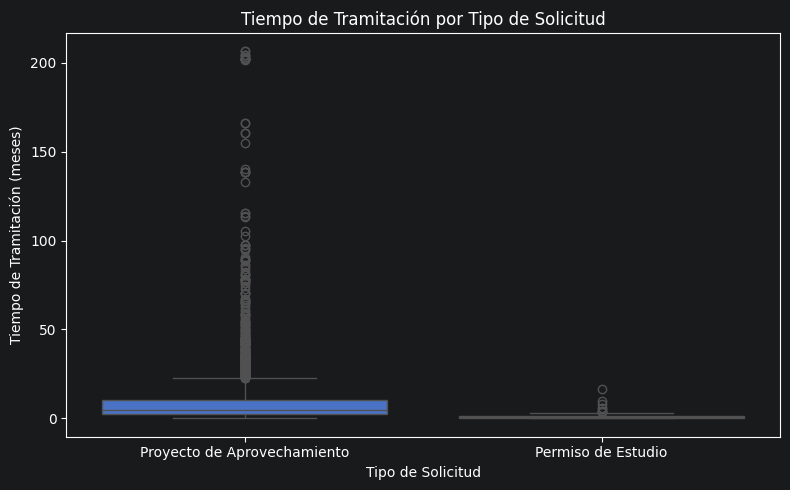

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Tipo de Solicitud",
    y="Tiempo de Tramitación"
)

plt.title("Tiempo de Tramitación por Tipo de Solicitud")
plt.xlabel("Tipo de Solicitud")
plt.ylabel("Tiempo de Tramitación (meses)")

plt.tight_layout()
plt.show()

El análisis del tiempo de tramitación según el tipo de solicitud evidencia diferencias significativas entre las categorías consideradas. Los expedientes correspondientes a Permisos de Estudio presentan tiempos de resolución considerablemente menores que los Proyectos de Aprovechamiento.

Mientras que los Permisos de Estudio registran una mediana de 0,84 meses y un tiempo promedio de 1,5 meses, los Proyectos de Aprovechamiento alcanzan una mediana de 4,73 meses y un promedio de 10,07 meses. Esta diferencia sugiere que los Permisos de Estudio constituyen trámites de menor complejidad administrativa y técnica, requiriendo tiempos de evaluación sustancialmente inferiores.

El diagrama de caja muestra además que la variabilidad observada en los tiempos de tramitación se concentra principalmente en los Proyectos de Aprovechamiento, categoría en la que se registran prácticamente todos los expedientes con demoras excepcionalmente elevadas.

Si bien la categoría Permiso de Estudio presenta una cantidad considerablemente menor de expedientes analizados (84 casos) en comparación con los Proyectos de Aprovechamiento (4614 casos), la diferencia observada en los tiempos de tramitación resulta suficientemente marcada como para evidenciar comportamientos distintos entre ambos tipos de solicitud. No obstante, los resultados asociados a los Permisos de Estudio deben interpretarse con cierta cautela debido al menor tamaño de la muestra.

En conjunto, los resultados indican que el tipo de solicitud constituye un factor relevante para explicar parte de la variabilidad observada en los tiempos de gestión de los expedientes, presentando los Permisos de Estudio tiempos de resolución significativamente inferiores a los Proyectos de Aprovechamiento.

A continuación se analiza la relación entre el Tiempo de Tramitación y la variable Uso, que clasifica los expedientes según el destino general previsto para el aprovechamiento del agua.

Este análisis permite evaluar si determinadas categorías de uso presentan tiempos de resolución sistemáticamente diferentes, lo que podría estar asociado a distintos niveles de complejidad técnica, requerimientos de evaluación o características particulares de los trámites.

In [83]:
uso_tiempo = (
    df
    .groupby("Uso")["Tiempo de Tramitación"]
    .agg(
        Cantidad="count",
        Promedio="mean",
        Mediana="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .round(2)
    .sort_values("Mediana", ascending=False)
)

print("Tiempo de Tramitación por Uso")
display(uso_tiempo)

Tiempo de Tramitación por Uso


,Cantidad,Promedio,Mediana,Q1,Q3
Uso,,,,,
Riego,1345,10.52,7.10,3.25,12.39
Otros usos agropecuarios,1384,13.19,5.45,2.50,20.93
Consumo humano,478,8.94,3.98,2.27,8.24
Industrial,836,7.56,3.58,2.04,6.28
Otros usos,640,5.53,2.96,1.45,5.00
Usos no consuntivos,15,4.47,2.86,2.18,3.42


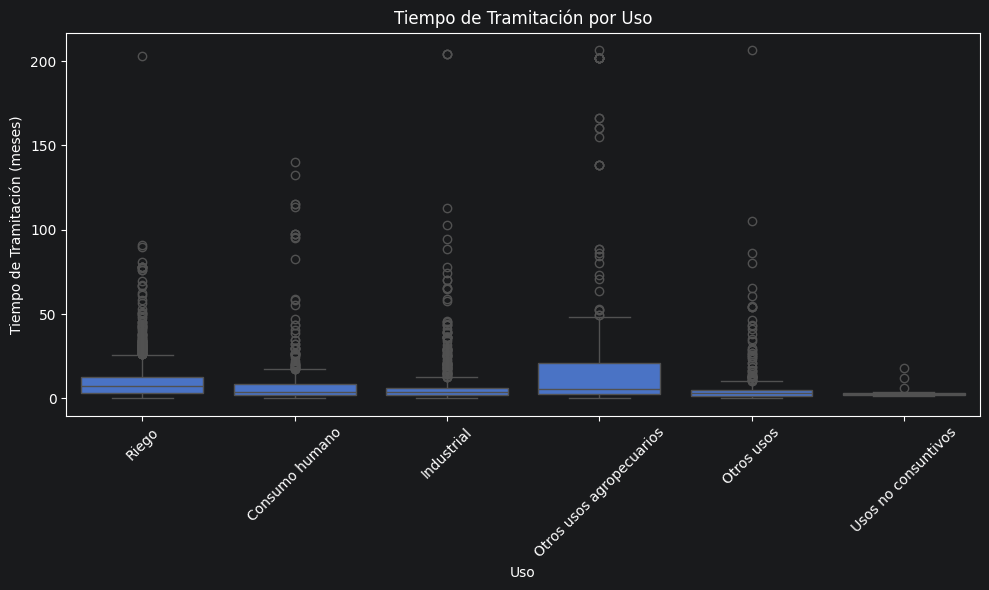

In [84]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Uso",
    y="Tiempo de Tramitación"
)

plt.title("Tiempo de Tramitación por Uso")
plt.xlabel("Uso")
plt.ylabel("Tiempo de Tramitación (meses)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El análisis del tiempo de tramitación según el uso previsto del aprovechamiento muestra diferencias relevantes entre las distintas categorías. Los expedientes asociados a Riego presentan los mayores tiempos típicos de resolución, con una mediana de 7,1 meses, seguidos por los correspondientes a Otros usos agropecuarios, cuya mediana alcanza los 5,45 meses.

Por su parte, los usos vinculados a Consumo humano e Industrial presentan tiempos intermedios, mientras que las categorías Otros usos y Usos no consuntivos registran los menores tiempos de tramitación. No obstante, esta última categoría debe interpretarse con cautela debido a la reducida cantidad de expedientes disponibles.

Asimismo, se observa que algunas categorías presentan diferencias importantes entre la media y la mediana, particularmente en el caso de Otros usos agropecuarios, lo que evidencia la presencia de expedientes con tiempos de resolución excepcionalmente elevados.

En conjunto, los resultados sugieren que el uso previsto del agua constituye un factor asociado a la duración de los trámites, observándose mayores tiempos de gestión en aquellos expedientes vinculados a actividades agropecuarias y de riego.

Hasta este punto, el análisis se centra principalmente en los expedientes que cuentan con una resolución registrada, permitiendo evaluar los tiempos de tramitación y los factores asociados a la duración de los procesos administrativos.

Para obtener una visión más completa de la gestión de los trámites, resulta relevante analizar también la situación de los expedientes que aún se encuentran pendientes de resolución. Este análisis permite caracterizar el stock actual de trámites en proceso e identificar posibles acumulaciones de expedientes.

Con este objetivo, se analizará la cantidad de expedientes pendientes, su antigüedad y su distribución según distintas variables administrativas, generando indicadores que complementan el estudio realizado sobre los trámites ya resueltos y aportan una perspectiva de la situación actual de la gestión.

In [85]:
df["Estado"].value_counts()

Estado
Registrada                 4700
En Estudio                  360
Pendiente de Resolución      99
Name: count, dtype: int64

Con el fin de analizar la situación actual de los expedientes que aún no han sido resueltos, se realiza una reclasificación de la variable Estado mediante la creación de una nueva columna Estado Agrupado. Dado que las categorías En Estudio y Pendiente de Resolución representan trámites que continúan en proceso, ambas son agrupadas en una única categoría denominada Pendiente.

Esta transformación permite diferenciar claramente los expedientes ya resueltos de aquellos que permanecen activos, facilitando la construcción de indicadores de gestión orientados a evaluar el volumen y la antigüedad de los trámites pendientes de resolución.

In [86]:
df["Estado Agrupado"] = df["Estado"].replace({
    "En Estudio": "Pendiente",
    "Pendiente de Resolución": "Pendiente"
})

In [87]:
df["Estado Agrupado"].value_counts()

Estado Agrupado
Registrada    4700
Pendiente      459
Name: count, dtype: int64

In [88]:
pendientes = df[df["Estado Agrupado"] == "Pendiente"].copy()

print("Cantidad de expedientes pendientes:", len(pendientes))

print(
    "Porcentaje sobre el total:",
    round(len(pendientes)/len(df)*100,2),
    "%"
)

Cantidad de expedientes pendientes: 459
Porcentaje sobre el total: 8.9 %


In [89]:
df.shape

(5159, 30)

Se verifican las dimensiones de la base de datos, constatándose que la transformación realizada no alteró la cantidad de registros. La base continuó conteniendo 5159 expedientes, incorporándose únicamente una nueva variable derivada para facilitar los análisis posteriores.

La agrupación de los estados permitió identificar la situación actual de los expedientes en trámite. Del total de 5159 expedientes analizados, 4700 cuentan con una resolución registrada, mientras que 459 permanecen pendientes, ya sea en etapa de estudio o pendientes de resolución.

En términos relativos, los expedientes pendientes representan aproximadamente el 8,9% del total de trámites incluidos en la base de datos. Este conjunto de expedientes constituye el stock actual de trámites en proceso y será analizado a continuación mediante indicadores de antigüedad, con el objetivo de evaluar su estado de avance y detectar posibles acumulaciones de expedientes sin resolver.

Una vez identificados los expedientes pendientes, se procede a analizar su situación actual. Se crea la variable Antigüedad Pendiente, definida como el tiempo transcurrido entre la fecha de solicitud y la fecha actual. Esta variable se calcula únicamente para los expedientes clasificados como pendientes, dejando valores vacíos para los trámites ya resueltos, dado que en estos casos la duración del proceso se encuentra representada por la variable Tiempo de Tramitación.

Este indicador constituye una herramienta relevante para la evaluación de la gestión, ya que permite identificar la existencia de expedientes con largos períodos de espera y caracterizar el estado actual de la cartera de trámites pendientes.

In [90]:
fecha_actual = pd.Timestamp.today()

df["Antigüedad Pendiente"] = np.where(
    df["Estado Agrupado"] == "Pendiente",
    (fecha_actual - df["Fecha de Solicitud"]).dt.days / 30.44,
    np.nan
)

In [91]:
df["Antigüedad Pendiente"].describe()

count    459.000000
mean      63.304146
std       70.449975
min        1.971091
25%        7.095926
50%       22.174770
75%      133.229304
max      347.601840
Name: Antigüedad Pendiente, dtype: float64

In [92]:
df["Antigüedad Pendiente"].notna().sum()

np.int64(459)

In [93]:
df.shape

(5159, 31)

Luego de incorporada la variable Antigüedad Pendiente, se verifican nuevamente las dimensiones de la base de datos con el fin de confirmar la integridad de los registros. Se constata que la incorporación de esta nueva variable no altera la cantidad de expedientes analizados, manteniéndose los 5159 registros originales y agregando una columna.

In [94]:
df[["Antigüedad Pendiente"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Antigüedad Pendiente,459.0,63.3,70.45,1.97,7.1,22.17,133.23,347.6


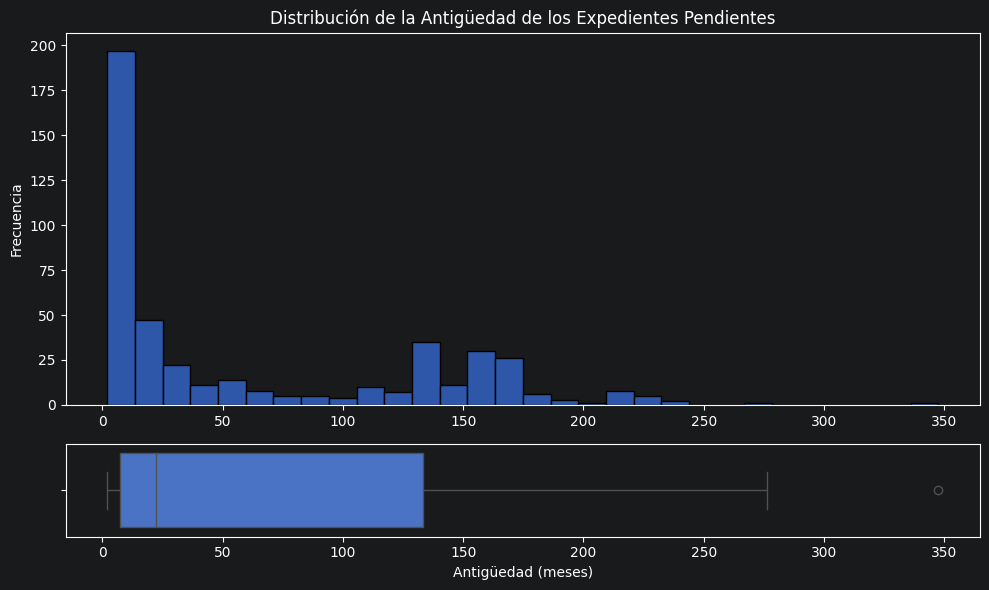

In [95]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [4, 1]}
)

sns.histplot(
    df["Antigüedad Pendiente"],
    bins=30,
    ax=ax1
)

ax1.set_title("Distribución de la Antigüedad de los Expedientes Pendientes")
ax1.set_xlabel("")
ax1.set_ylabel("Frecuencia")

sns.boxplot(
    x=df["Antigüedad Pendiente"],
    ax=ax2
)

ax2.set_xlabel("Antigüedad (meses)")

plt.tight_layout()
plt.show()

El análisis de la antigüedad de los expedientes pendientes evidencia una elevada heterogeneidad en los tiempos de permanencia de los trámites sin resolución. Mientras que el 25% de los expedientes presenta una antigüedad inferior a 7 meses, la mediana alcanza los 22,1 meses, indicando que la mitad de los trámites pendientes lleva casi dos años en proceso.

Asimismo, el tercer cuartil se sitúa en 133,2 meses, lo que refleja la existencia de un número significativo de expedientes con antigüedades muy elevadas. Esta situación se ve reflejada también en la diferencia entre la media (63,3 meses) y la mediana (22,1 meses), así como en la presencia de expedientes que superan los 347 meses de antigüedad.

El histograma y el diagrama de caja muestran una distribución fuertemente asimétrica hacia la derecha, caracterizada por un conjunto de expedientes históricos que permanecen pendientes desde hace varios años. Estos resultados sugieren que la cartera actual de trámites pendientes está compuesta tanto por expedientes recientes como por un grupo de casos de larga data que contribuyen significativamente a incrementar la antigüedad promedio de los trámites en proceso.

In [96]:
pendientes_regional = (
    df["Regional"]
    .value_counts()
    .to_frame("Cantidad")
)

pendientes_regional["Porcentaje"] = (
    pendientes_regional["Cantidad"]
    / pendientes_regional["Cantidad"].sum()
    * 100
).round(2)

pendientes_regional

,Cantidad,Porcentaje
Regional,,
MONTEVIDEO,1180,22.88
FRAY BENTOS,929,18.01
SAN JOSÉ,929,18.01
SALTO,598,11.60
SAN JOSÉ ESTE,388,7.52
DURAZNO,306,5.93
ROCHA,303,5.88
TACUAREMBÓ,233,4.52
TREINTA Y TRES,151,2.93


In [97]:
antiguedad_regional = (
    df
    .groupby("Regional")["Antigüedad Pendiente"]
    .agg(
        Cantidad="count",
        Mediana="median",
        Promedio="mean"
    )
    .round(2)
    .sort_values("Mediana", ascending=False)
)

antiguedad_regional

,Cantidad,Mediana,Promedio
Regional,,,
TACUAREMBÓ,35,128.45,99.01
DURAZNO,23,119.38,99.54
RÍO BRANCO,10,66.03,60.15
TREINTA Y TRES,11,50.66,69.97
FRAY BENTOS,72,30.80,69.13
SALTO,74,25.38,68.61
ROCHA,49,23.36,74.44
MONTEVIDEO,72,12.39,46.30
SAN JOSÉ ESTE,31,10.48,62.97


La distribución de la antigüedad de los expedientes pendientes por regional evidencia diferencias importantes entre oficinas. Considerando la mediana como medida principal de comparación, se observa que las regionales de Tacuarembó y Durazno presentan los expedientes pendientes más antiguos, con medianas de 128,4 y 119,4 meses respectivamente.

Por su parte, las regionales de Montevideo, San José y San José Este registran las menores antigüedades medianas, con valores cercanos a un año. Estos resultados sugieren diferencias significativas en la antigüedad de pendientes entre regionales.

Asimismo, se observa que algunas oficinas presentan una elevada diferencia entre la media y la mediana, lo que indica la presencia de expedientes particularmente antiguos que incrementan la antigüedad promedio de los trámites pendientes.

Si bien algunas regionales cuentan con una cantidad reducida de expedientes pendientes, los resultados permiten identificar sectores donde se concentra una proporción importante de trámites de larga data, constituyendo potenciales áreas de atención para la gestión de los expedientes en proceso.

In [98]:
tiempo_regional = (
    df
    .groupby("Regional")["Tiempo de Tramitación"]
    .agg(
        Cantidad="count",
        Promedio="mean",
        Mediana="median"
    )
    .round(2)
)

comparacion = pd.concat(
    [
        tiempo_regional["Mediana"],
        antiguedad_regional["Mediana"]
    ],
    axis=1
)

comparacion.columns = [
    "Mediana Tiempo Tramitación",
    "Mediana Antigüedad Pendientes"
]

comparacion.sort_values(
    "Mediana Antigüedad Pendientes",
    ascending=False
)

,Mediana Tiempo Tramitación,Mediana Antigüedad Pendientes
Regional,,
TACUAREMBÓ,4.48,128.45
DURAZNO,3.75,119.38
RÍO BRANCO,7.49,66.03
TREINTA Y TRES,5.12,50.66
FRAY BENTOS,5.22,30.80
SALTO,6.87,25.38
ROCHA,4.30,23.36
MONTEVIDEO,3.78,12.39
SAN JOSÉ ESTE,3.88,10.48


La comparación entre los tiempos de tramitación de los expedientes resueltos y la antigüedad de los expedientes pendientes evidencia que ambas métricas aportan perspectivas complementarias sobre la gestión de los trámites.

Mientras que el tiempo de tramitación refleja la duración de los expedientes que alcanzaron una resolución, la antigüedad de los pendientes permite evaluar la situación actual de los trámites que permanecen abiertos. En este sentido, no se observa una relación directa entre ambas medidas. Algunas regionales, como Tacuarembó y Durazno, presentan tiempos de tramitación relativamente bajos para los expedientes resueltos, pero muestran antigüedades muy elevadas en sus expedientes pendientes.

Estos resultados sugieren que el análisis exclusivo de los expedientes resueltos no resulta suficiente para caracterizar completamente la gestión de los trámites, siendo necesario complementar dicha evaluación con indicadores asociados a la cartera de expedientes pendientes. De esta forma, es posible identificar regionales donde persisten trámites históricos que no quedan reflejados en los tiempos de resolución observados para los expedientes ya finalizados.

#### Conclusiones

El presente Análisis Exploratorio de Datos permitió caracterizar los expedientes de solicitud de uso de aguas públicas y estudiar los principales factores asociados a los tiempos de tramitación.

Durante la etapa de preparación de los datos se realizaron diversas tareas de limpieza y transformación orientadas a mejorar la calidad de la información. Entre ellas se incluyeron la eliminación de registros y variables con escasa utilidad analítica o elevados niveles de valores faltantes, la corrección y conversión de formatos de fechas y variables numéricas, la identificación de inconsistencias en los datos y la generación de nuevas variables derivadas. En particular, se detectaron y corrigieron expedientes con fechas de solicitud y resolución invertidas, permitiendo obtener una medida consistente del Tiempo de Tramitación. Asimismo, se creó la variable Antigüedad de los Expedientes Pendientes, que permitió evaluar la situación actual de los trámites que aún no cuentan con resolución.

El análisis de las variables numéricas evidenció que las características técnicas de las perforaciones, tales como caudal, volumen, profundidad, diámetro y niveles hidráulicos, presentan correlaciones prácticamente nulas con los tiempos de tramitación. Esto sugiere que la duración de los expedientes no depende de las características físicas de las obras solicitadas.

Por el contrario, las variables administrativas mostraron una mayor capacidad explicativa. Se observaron diferencias entre regionales, aunque de magnitud moderada, mientras que variables como el Tipo de Solicitud y el Uso previsto del agua evidenciaron diferencias más significativas en los tiempos de resolución. En particular, los Permisos de Estudio presentan tiempos de tramitación considerablemente menores que los Proyectos de Aprovechamiento, y los usos vinculados al Riego y a Otros usos agropecuarios registran los mayores tiempos de gestión.

Respecto a la situación actual de los expedientes, se identificaron 459 trámites pendientes, equivalentes a aproximadamente el 8,9% del total de registros analizados. El estudio de su antigüedad mostró una elevada heterogeneidad, coexistiendo expedientes recientes con otros que permanecen abiertos desde hace varios años. Asimismo, se detectaron diferencias importantes entre regionales en la antigüedad de los expedientes pendientes, evidenciando la presencia de carteras históricas de trámites aún sin resolver.

En conjunto, los resultados indican que los tiempos de tramitación están más asociados a factores administrativos y al tipo de trámite gestionado que a las características técnicas de las perforaciones asociadas a las solicitudes. Asimismo, el análisis de los expedientes pendientes permitió complementar la evaluación histórica de los trámites resueltos, aportando una visión más completa del estado actual de la gestión.

In [99]:
##Guardado de la base de datos procesada

df.to_csv(
    "../data/processed/tramites_procesados.csv",
    index=False,
    encoding="utf-8-sig"
)

In [100]:
import os

os.path.exists("../data/processed/tramites_procesados.csv")

True

In [101]:
df_verificacion = pd.read_csv(
    "../data/processed/tramites_procesados.csv",
    encoding="utf-8-sig"
)

df_verificacion.shape

(5159, 31)